In [4]:
import pandas as pd
import numpy as np
import os
import glob

# =============================================================================
# STEP 1: LOAD DATA WITH CORRECT ENCODING
# =============================================================================
# FIX: Added encoding='latin-1' to handle Greek letters (α, β, γ, δ)

master_file_path = r"/content/Master_File.xlsx"
directory = r"/content/"

# Option 1: If loading from multiple CSVs
dfs = []
file_paths = glob.glob(f"{directory}*.csv")

if not file_paths:
    print(f"Warning: No CSV files found in {directory}")
    # Option 2: Load the sample data directly
    full_df = pd.read_csv('/mnt/user-data/uploads/Sample_data.csv', encoding='latin-1')
    print(f"✓ Loaded sample data: {full_df.shape[0]:,} total rows")
else:
    for file in file_paths:
        temp_df = pd.read_csv(file, encoding='latin-1')  # ← FIX: Added encoding
        dfs.append(temp_df)

    full_df = pd.concat(dfs, ignore_index=True)
    print(f"✓ Loaded {len(file_paths)} files: {full_df.shape[0]:,} total rows")

print(f"Initial shape: {full_df.shape}")
print(f"\nFuel types: {full_df['Fuel_Type'].value_counts().to_dict()}")

# =============================================================================
# STEP 2: MAP FUEL SPECIES TO FUEL FAMILIES (PAPER METHOD)
# =============================================================================
# Paper grouped fuels into: Pine, Fir, Spruce
# You have: ponderosa, lodgepole (pines), Doug fir, subalpine (firs),
#           Engelmann (spruce), manzanita (shrub)

fuel_family_map = {
    'ponderosa': 'Pine',
    'lodgepole': 'Pine',
    'Doug fir': 'Fir',
    'subalpine': 'Fir',
    'Engelmann': 'Spruce',
    'manzanita': 'Shrub'  # Not in paper, but keeping it
}

full_df['Fuel_Family'] = full_df['Fuel_Type'].map(fuel_family_map)

print("\n" + "="*70)
print("STEP 2: MAP TO FUEL FAMILIES (PAPER METHOD)")
print("="*70)
print(f"✓ Fuel families created:")
print(full_df['Fuel_Family'].value_counts())

# =============================================================================
# STEP 3: FILTER FOR MONOTERPENOIDS ONLY (PAPER METHOD)
# =============================================================================
# Paper used only monoterpenoids (C10H16 and C10H16O)
# Your data has MT (monoterpenoid) and SQT (sesquiterpene) isomers

# Get compound columns (skip metadata)
metadata_cols = ['Burn_No', 'Fuel_Type', 'Fuel_Comp', 'Fuel_Family']
compound_cols = [col for col in full_df.columns if col not in metadata_cols]

# Filter to keep only monoterpenoids (exclude SQT isomers and unknowns)
# You can refine this list based on your specific compounds
mt_keywords = ['MT isomer', 'Tricyclene', 'Thujene', 'Pinene', 'fenchene',
               'Camphene', 'Sabinene', 'Myrcene', 'Phellandrene', 'Carene',
               'Terpinene', 'Cymene', 'Limonene', 'Eucalyptol', 'Ocimene',
               'Linalool', 'Fenchone', 'Pinocarveol', 'camphor', 'Pinocarvone',
               'Borneol', 'Terpineol', 'Estragole', 'Myrtenal', 'Myrtenol',
               'Fenchyl', 'Chrysanthenol', 'Bornyl', 'Thymol', 'Terpinyl',
               'Santene', 'Santolina', 'Artemiseole']

# Keep only monoterpenoid columns
mt_cols = [col for col in compound_cols
           if any(keyword.lower() in col.lower() for keyword in mt_keywords)
           and 'SQT' not in col]  # Exclude sesquiterpenes

full_df_mt = full_df[metadata_cols + mt_cols].copy()

print("\n" + "="*70)
print("STEP 3: FILTER FOR MONOTERPENOIDS")
print("="*70)
print(f"✓ Total compounds before: {len(compound_cols)}")
print(f"✓ Monoterpenoids retained: {len(mt_cols)}")
print(f"  Removed: {len(compound_cols) - len(mt_cols)} (SQT and other)")

# =============================================================================
# STEP 4: FILTER SAMPLES BY FUEL FAMILY (PAPER CRITERION 1)
# =============================================================================
# Paper kept only fuel types with >30% of monoterpenoids detected

# Calculate detection rate per sample (% non-zero, non-NaN values)
detection_rate = ((full_df_mt[mt_cols].notna()) & (full_df_mt[mt_cols] > 0)).sum(axis=1) / len(mt_cols) * 100

# Keep only samples with >30% detection
full_df_filtered = full_df_mt[detection_rate > 30].copy()

print("\n" + "="*70)
print("STEP 4: FILTER SAMPLES BY DETECTION RATE (PAPER METHOD)")
print("="*70)
print(f"✓ Samples before: {len(full_df_mt)}")
print(f"✓ Samples after (>30% detection): {len(full_df_filtered)}")
print(f"  Removed: {len(full_df_mt) - len(full_df_filtered)} samples")

# Show remaining samples by fuel family
print(f"\nRemaining samples by fuel family:")
print(full_df_filtered['Fuel_Family'].value_counts())

# =============================================================================
# STEP 5: FILTER FUEL FAMILIES (PAPER CRITERION 2)
# =============================================================================
# Paper kept only fuel families with ≥3 samples

fuel_family_counts = full_df_filtered['Fuel_Family'].value_counts()
valid_families = fuel_family_counts[fuel_family_counts >= 3].index

full_df_filtered = full_df_filtered[full_df_filtered['Fuel_Family'].isin(valid_families)].copy()

print("\n" + "="*70)
print("STEP 5: FILTER FUEL FAMILIES (≥3 SAMPLES)")
print("="*70)
print(f"✓ Fuel families retained:")
print(full_df_filtered['Fuel_Family'].value_counts())

# =============================================================================
# STEP 6: FILTER COMPOUNDS BY MISSINGNESS (PAPER METHOD)
# =============================================================================
# Paper: Drop compounds with >30% missing values (NOT 50% like your original code)

# Calculate missingness per compound
mt_cols_updated = [col for col in full_df_filtered.columns if col not in metadata_cols]
missing_pct = full_df_filtered[mt_cols_updated].isna().mean() * 100

# Keep only compounds with ≤30% missing
good_compounds = missing_pct[missing_pct <= 30].index.tolist()

full_df_clean = full_df_filtered[metadata_cols + good_compounds].copy()

print("\n" + "="*70)
print("STEP 6: FILTER COMPOUNDS BY MISSINGNESS (≤30%)")
print("="*70)
print(f"✓ Compounds before: {len(mt_cols_updated)}")
print(f"✓ Compounds after (≤30% missing): {len(good_compounds)}")
print(f"  Removed: {len(mt_cols_updated) - len(good_compounds)}")

# =============================================================================
# STEP 7: FILL REMAINING MISSING VALUES (PAPER METHOD)
# =============================================================================
# Paper: Replace remaining missing values (≤30%) with zeros

compound_cols_final = [col for col in full_df_clean.columns if col not in metadata_cols]
full_df_clean[compound_cols_final] = full_df_clean[compound_cols_final].fillna(0)

print("\n" + "="*70)
print("STEP 7: FILL MISSING VALUES WITH ZERO")
print("="*70)
print(f"✓ Filled remaining missing values with 0")
print(f"  Remaining NaN values: {full_df_clean[compound_cols_final].isna().sum().sum()}")

# =============================================================================
# STEP 8: NORMALIZE DATA
# =============================================================================
# Paper used NEMR (normalized to CO), but if you don't have CO data,
# use TIC normalization (relative abundance)

# Option A: TIC normalization (what you're currently doing)
row_sums = full_df_clean[compound_cols_final].sum(axis=1)
df_normalized = full_df_clean.copy()
df_normalized[compound_cols_final] = full_df_clean[compound_cols_final].div(row_sums, axis=0)

print("\n" + "="*70)
print("STEP 8: NORMALIZE BY TIC")
print("="*70)
print(f"✓ TIC normalized: each sample sums to 1.0")
print(f"  Example row sum: {df_normalized[compound_cols_final].iloc[0].sum():.6f}")

# Option B: If you had CO data (PAPER METHOD - NEMR)
# Uncomment this if you have CO measurements:
# df_normalized = full_df_clean.copy()
# df_normalized[compound_cols_final] = full_df_clean[compound_cols_final].div(
#     full_df_clean['CO_area'], axis=0
# )

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "="*70)
print("FINAL CLEANED DATA SUMMARY")
print("="*70)
print(f"Final shape: {df_normalized.shape}")
print(f"Samples: {len(df_normalized)}")
print(f"Compounds: {len(compound_cols_final)}")
print(f"\nSamples per fuel family:")
print(df_normalized['Fuel_Family'].value_counts())

# Display first few rows
print("\n" + "="*70)
print("FIRST 5 CLEANED SAMPLES")
print("="*70)
print(df_normalized.head())

# # =============================================================================
# # SAVE CLEANED DATA
# # =============================================================================
# # Save for use in ML pipeline
# df_normalized.to_csv('/mnt/user-data/outputs/cleaned_data_paper_method.csv', index=False)
# print(f"\n✓ Saved cleaned data to: cleaned_data_paper_method.csv")

# # Also save the compound list for reference
# with open('/mnt/user-data/outputs/selected_compounds.txt', 'w') as f:
#     f.write("Selected Monoterpenoid Compounds\n")
#     f.write("="*50 + "\n")
#     for i, compound in enumerate(compound_cols_final, 1):
#         f.write(f"{i}. {compound}\n")
# print(f"✓ Saved compound list to: selected_compounds.txt")

✓ Loaded 1 files: 50 total rows
Initial shape: (50, 100)

Fuel types: {'ponderosa': 11, 'Doug fir': 10, 'Engelmann': 10, 'lodgepole': 9, 'subalpine': 6, 'manzanita': 4}

STEP 2: MAP TO FUEL FAMILIES (PAPER METHOD)
✓ Fuel families created:
Fuel_Family
Pine      20
Fir       16
Spruce    10
Shrub      4
Name: count, dtype: int64

STEP 3: FILTER FOR MONOTERPENOIDS
✓ Total compounds before: 97
✓ Monoterpenoids retained: 57
  Removed: 40 (SQT and other)

STEP 4: FILTER SAMPLES BY DETECTION RATE (PAPER METHOD)
✓ Samples before: 50
✓ Samples after (>30% detection): 22
  Removed: 28 samples

Remaining samples by fuel family:
Fuel_Family
Fir       10
Pine      10
Spruce     2
Name: count, dtype: int64

STEP 5: FILTER FUEL FAMILIES (≥3 SAMPLES)
✓ Fuel families retained:
Fuel_Family
Fir     10
Pine    10
Name: count, dtype: int64

STEP 6: FILTER COMPOUNDS BY MISSINGNESS (≤30%)
✓ Compounds before: 57
✓ Compounds after (≤30% missing): 18
  Removed: 39

STEP 7: FILL MISSING VALUES WITH ZERO
✓ Filled

In [8]:
"""
STEP-BY-STEP ANALYSIS AFTER DATA CLEANING
Run this IMMEDIATELY after your data cleaning code
Assumes df_normalized (or df_tic) already exists in memory
"""

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 300

print("="*80)
print("STEP-BY-STEP MACHINE LEARNING PIPELINE")
print("="*80)

# =============================================================================
# STEP 9: USE CLEANED DATA FROM MEMORY
# =============================================================================
print("\n" + "="*80)
print("STEP 9: PREPARE CLEANED DATA")
print("="*80)

# Use the dataframe you just created from cleaning
# Change 'df_normalized' to whatever your final cleaned dataframe is called
df_cleaned = df_normalized.copy()

print(f"✓ Using cleaned data from memory: {df_cleaned.shape}")
print(f"\nAvailable columns:")
print(df_cleaned.columns.tolist())

# =============================================================================
# STEP 10: MAP FUEL SPECIES TO FAMILIES (if not done already)
# =============================================================================
print("\n" + "="*80)
print("STEP 10: CREATE FUEL FAMILIES")
print("="*80)

# Check if Fuel_Family column already exists
if 'Fuel_Family' not in df_cleaned.columns:
    # Map your fuel types to families
    # ADJUST THIS based on your actual fuel types!
    fuel_family_map = {
        'ponderosa': 'Pine',
        'lodgepole': 'Pine',
        'Doug fir': 'Fir',
        'subalpine': 'Fir',
        'Engelmann': 'Spruce',
        'manzanita': 'Shrub'
    }

    # Create Fuel_Family column
    # CHANGE 'Fuel_Type' to whatever column has your fuel names
    df_cleaned['Fuel_Family'] = df_cleaned['Fuel_Type'].map(fuel_family_map)
    print("✓ Created Fuel_Family column")
else:
    print("✓ Fuel_Family column already exists")

print(f"\nFuel families present:")
print(df_cleaned['Fuel_Family'].value_counts())

# =============================================================================
# STEP 11: IDENTIFY COMPOUND COLUMNS
# =============================================================================
print("\n" + "="*80)
print("STEP 11: IDENTIFY COMPOUND COLUMNS")
print("="*80)

# Define which columns are metadata (not compounds)
# ADJUST THIS based on your actual column names!
metadata_cols = ['Sample Name', 'Sample Type', 'Burn_No', 'Fuel_Type',
                 'Fuel_Comp', 'Fuel_Family']

# Keep only metadata columns that actually exist
metadata_cols = [col for col in metadata_cols if col in df_cleaned.columns]

# Everything else is a compound
compound_cols = [col for col in df_cleaned.columns if col not in metadata_cols]

print(f"✓ Metadata columns: {metadata_cols}")
print(f"✓ Compound columns: {len(compound_cols)}")
print(f"✓ Total samples: {len(df_cleaned)}")

# =============================================================================
# STEP 12: PREPARE FEATURE MATRIX AND LABELS
# =============================================================================
print("\n" + "="*80)
print("STEP 12: PREPARE FEATURES AND LABELS")
print("="*80)

# X = feature matrix (compound concentrations)
# y = labels (fuel families)
X = df_cleaned[compound_cols].values
y = df_cleaned['Fuel_Family'].values

print(f"✓ Feature matrix (X): {X.shape}")
print(f"✓ Labels (y): {y.shape}")
print(f"\nLabel distribution:")
for fuel in np.unique(y):
    count = (y == fuel).sum()
    print(f"  {fuel}: {count} samples")

# CRITICAL CHECK
if 'Zero_Air_Generator' in y or 'Medical_Grade_Air' in y:
    print("\n⚠️ WARNING: Labels contain blank sample types!")
    print("   Consider filtering these out or using different grouping")
else:
    print("\n✅ Labels look correct")

# =============================================================================
# STEP 13: STANDARDIZATION (CRITICAL!)
# =============================================================================
print("\n" + "="*80)
print("STEP 13: STANDARDIZATION")
print("="*80)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✓ Features standardized to mean=0, std=1")
print(f"\nBefore standardization:")
print(f"  Mean: {X[:, 0].mean():.6f}")
print(f"  Std:  {X[:, 0].std():.6f}")
print(f"\nAfter standardization:")
print(f"  Mean: {X_scaled[:, 0].mean():.10f}")
print(f"  Std:  {X_scaled[:, 0].std():.6f}")

STEP-BY-STEP MACHINE LEARNING PIPELINE

STEP 9: PREPARE CLEANED DATA
✓ Using cleaned data from memory: (20, 22)

Available columns:
['Burn_No', 'Fuel_Type', 'Fuel_Comp', 'Fuel_Family', 'MT isomer', 'Tricyclene', '?Ý-Thujene', '?Ý-Pinene', 'Camphene', 'MT isomer.3', 'Sabinene', 'beta-Pinene', '?°-Myrcene', 'MT isomer.10', '3-Carene', 'p-Cymene', 'D-Limonene', '?°-Ocimene', '?ß-Terpinene', 'MT isomer.13', 'L-Pinocarveol', 'Myrtenal']

STEP 10: CREATE FUEL FAMILIES
✓ Fuel_Family column already exists

Fuel families present:
Fuel_Family
Fir     10
Pine    10
Name: count, dtype: int64

STEP 11: IDENTIFY COMPOUND COLUMNS
✓ Metadata columns: ['Burn_No', 'Fuel_Type', 'Fuel_Comp', 'Fuel_Family']
✓ Compound columns: 18
✓ Total samples: 20

STEP 12: PREPARE FEATURES AND LABELS
✓ Feature matrix (X): (20, 18)
✓ Labels (y): (20,)

Label distribution:
  Fir: 10 samples
  Pine: 10 samples

✅ Labels look correct

STEP 13: STANDARDIZATION
✓ Features standardized to mean=0, std=1

Before standardization:


STEP 14: ANOVA FEATURE SELECTION
Calculating F-ratios for 18 compounds
Grouping by: ['Fir', 'Pine']

TOP 20 COMPOUNDS BY F-RATIO
     Compound    F-ratio      p-value
     Camphene 133.988423 8.993526e-10
   Tricyclene 115.280750 2.957963e-09
     Myrtenal  79.040589 5.282911e-08
  beta-Pinene  77.061401 6.372757e-08
     3-Carene  61.334222 3.313489e-07
   ?°-Myrcene  57.373310 5.289744e-07
 MT isomer.13  16.764498 6.805776e-04
 MT isomer.10  13.185624 1.909898e-03
   D-Limonene   8.413540 9.532821e-03
 ?ß-Terpinene   2.761399 1.138803e-01
L-Pinocarveol   2.383390 1.400300e-01
   ?Ý-Thujene   1.936561 1.810024e-01
   ?°-Ocimene   1.636354 2.170717e-01
     p-Cymene   1.524750 2.327790e-01
    MT isomer   0.823385 3.761808e-01
    ?Ý-Pinene   0.424704 5.228338e-01
  MT isomer.3   0.326525 5.747792e-01
     Sabinene   0.093654 7.630935e-01

✓ Compounds with p < 0.05: 9/18

STEP 15: SELECT TOP COMPOUNDS
✓ Selected top 5 compounds:

  1. Camphene
     F-ratio: 133.99, p-value: 0.000000
 

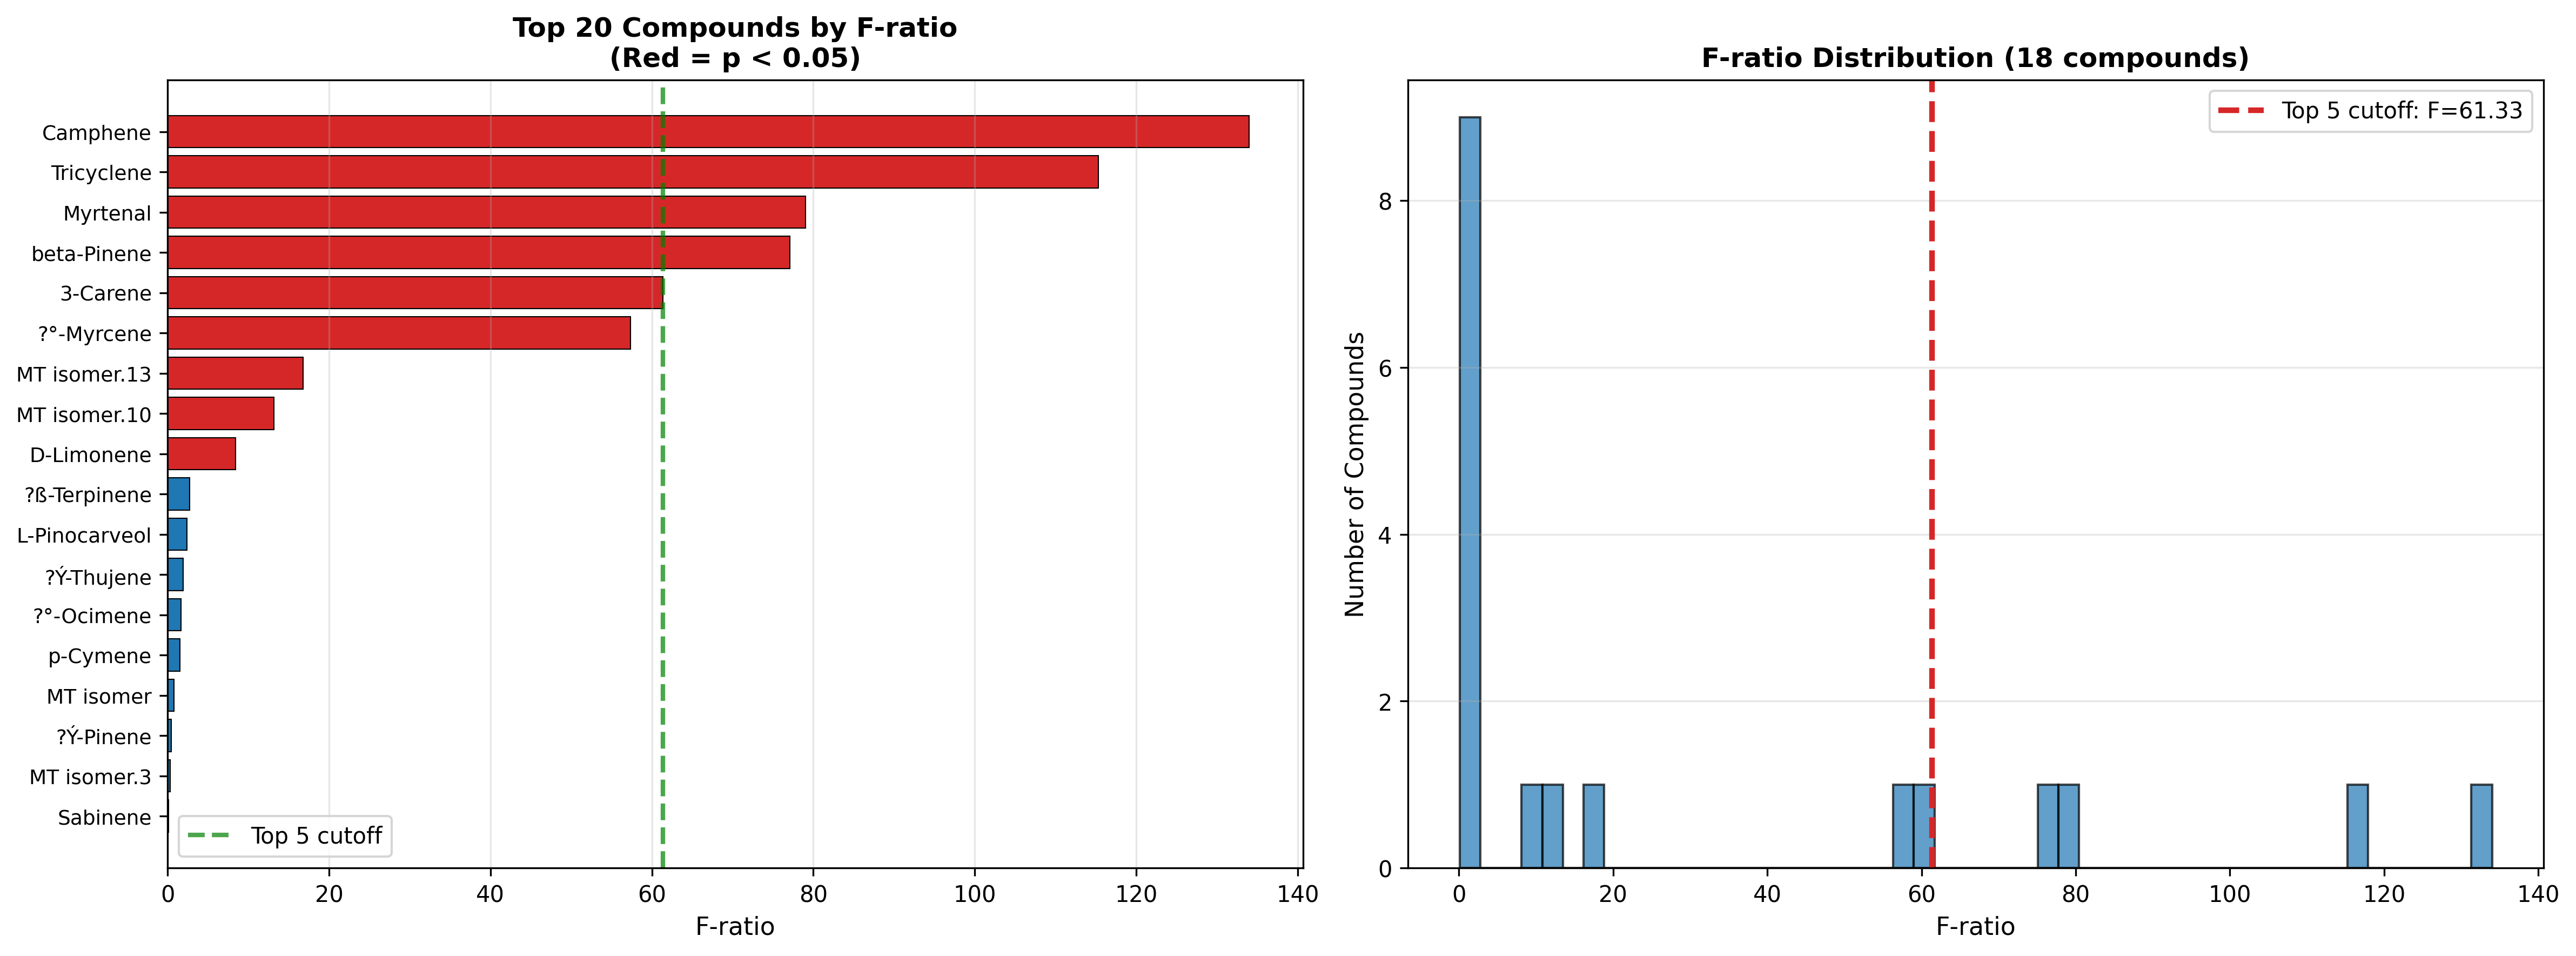


FEATURE SELECTION COMPLETE!

Starting: 18 compounds
Selected: 5 compounds (27.8%)
Reduction: 72.2%

Significant (p < 0.05): 9/18

✅ Variables created:
   - X_selected: standardized selected features
   - y: fuel family labels
   - top_compounds: list of selected compound names


In [9]:
# =============================================================================
# STEP 14: ANOVA FEATURE SELECTION (F-RATIO)
# =============================================================================
print("\n" + "="*80)
print("STEP 14: ANOVA FEATURE SELECTION")
print("="*80)

f_ratios = {}
p_values = {}

fuel_families = np.unique(y)
print(f"Calculating F-ratios for {len(compound_cols)} compounds")
print(f"Grouping by: {list(fuel_families)}\n")

for i, col_name in enumerate(compound_cols):
    compound_data = X_scaled[:, i]
    groups = [compound_data[y == fuel] for fuel in fuel_families]
    f_stat, p_val = stats.f_oneway(*groups)
    f_ratios[col_name] = f_stat
    p_values[col_name] = p_val

# Create results DataFrame
f_df = pd.DataFrame({
    'Compound': list(f_ratios.keys()),
    'F-ratio': list(f_ratios.values()),
    'p-value': list(p_values.values())
})

f_df = f_df.sort_values(by='F-ratio', ascending=False).reset_index(drop=True)

print("="*80)
print("TOP 20 COMPOUNDS BY F-RATIO")
print("="*80)
print(f_df.head(20).to_string(index=False))

significant = (f_df['p-value'] < 0.05).sum()
print(f"\n✓ Compounds with p < 0.05: {significant}/{len(f_df)}")

# =============================================================================
# STEP 15: SELECT TOP COMPOUNDS
# =============================================================================
print("\n" + "="*80)
print("STEP 15: SELECT TOP COMPOUNDS")
print("="*80)

n_features = 5  # Paper used 5

top_compounds = f_df.head(n_features)['Compound'].tolist()

print(f"✓ Selected top {n_features} compounds:\n")
for i, compound in enumerate(top_compounds, 1):
    f_ratio = f_df[f_df['Compound'] == compound]['F-ratio'].values[0]
    p_val = f_df[f_df['Compound'] == compound]['p-value'].values[0]
    print(f"  {i}. {compound}")
    print(f"     F-ratio: {f_ratio:.2f}, p-value: {p_val:.6f}")

# =============================================================================
# STEP 16: CREATE FILTERED DATASET
# =============================================================================
print("\n" + "="*80)
print("STEP 16: CREATE FILTERED DATASET")
print("="*80)

selected_indices = [compound_cols.index(comp) for comp in top_compounds]
X_selected = X_scaled[:, selected_indices]

print(f"✓ Filtered feature matrix: {X_selected.shape}")
print(f"  Original: {X_scaled.shape[1]} compounds")
print(f"  Selected: {X_selected.shape[1]} compounds")
print(f"  Reduction: {(1 - X_selected.shape[1]/X_scaled.shape[1])*100:.1f}%")

# =============================================================================
# STEP 17: VISUALIZE
# =============================================================================
print("\n" + "="*80)
print("STEP 17: VISUALIZE RESULTS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 20 F-ratios
ax1 = axes[0]
top_20 = f_df.head(20)
colors = ['#d62728' if p < 0.05 else '#1f77b4' for p in top_20['p-value']]
labels = [c[:35] + '...' if len(c) > 35 else c for c in top_20['Compound']]

ax1.barh(range(len(top_20)), top_20['F-ratio'], color=colors, edgecolor='black', linewidth=0.5)
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(labels, fontsize=9)
ax1.set_xlabel('F-ratio', fontsize=11)
ax1.set_title('Top 20 Compounds by F-ratio\n(Red = p < 0.05)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

if n_features <= 20:
    cutoff = top_20.iloc[n_features-1]['F-ratio']
    ax1.axvline(x=cutoff, color='green', linestyle='--', linewidth=2,
                label=f'Top {n_features} cutoff', alpha=0.7)
    ax1.legend(fontsize=10)

# Plot 2: Distribution
ax2 = axes[1]
ax2.hist(f_df['F-ratio'], bins=50, color='#1f77b4', edgecolor='black', alpha=0.7)

cutoff = f_df['F-ratio'].iloc[n_features-1]
ax2.axvline(x=cutoff, color='#d62728', linestyle='--', linewidth=2.5,
            label=f'Top {n_features} cutoff: F={cutoff:.2f}')

ax2.set_xlabel('F-ratio', fontsize=11)
ax2.set_ylabel('Number of Compounds', fontsize=11)
ax2.set_title(f'F-ratio Distribution ({len(f_df)} compounds)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('f_ratio_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: f_ratio_analysis.png")
plt.show()

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "="*80)
print("FEATURE SELECTION COMPLETE!")
print("="*80)
print(f"\nStarting: {len(compound_cols)} compounds")
print(f"Selected: {n_features} compounds ({(n_features/len(compound_cols)*100):.1f}%)")
print(f"Reduction: {(1 - n_features/len(compound_cols))*100:.1f}%")
print(f"\nSignificant (p < 0.05): {significant}/{len(f_df)}")
print(f"\n✅ Variables created:")
print(f"   - X_selected: standardized selected features")
print(f"   - y: fuel family labels")
print(f"   - top_compounds: list of selected compound names")


STEP 18: PRINCIPAL COMPONENT ANALYSIS
✓ Using selected features from memory
  Feature matrix: (20, 5)
  Labels: (20,)
  Already standardized: Yes

VARIANCE EXPLAINED ANALYSIS
✓ Components for 80% variance: 1

Variance by component:
  PC1:  87.28%  (cumulative:  87.28%)
  PC2:   5.47%  (cumulative:  92.76%)
  PC3:   2.99%  (cumulative:  95.75%)
  PC4:   2.28%  (cumulative:  98.03%)
  PC5:   1.97%  (cumulative: 100.00%)

✓ PCA transformation complete
  PCA scores shape: (20, 5)

PCA RESULTS DATAFRAME
        PC1       PC2       PC3       PC4       PC5 Fuel_Family Sample_Name
0  2.349974 -0.106401  0.032651  0.201055 -0.212496         Fir      burn11
1  2.262043 -0.297489  0.236624 -0.498571  0.560204         Fir      burn14
2  2.497120 -0.100215 -0.343933  0.458239  0.213505         Fir      burn18
3  2.238349 -0.036873 -0.277650  0.495784 -0.111513         Fir      burn45
4  2.317948 -0.355886 -0.031882 -0.291247  0.538127         Fir      burn57

✓ Saved: pca_variance_explained.png


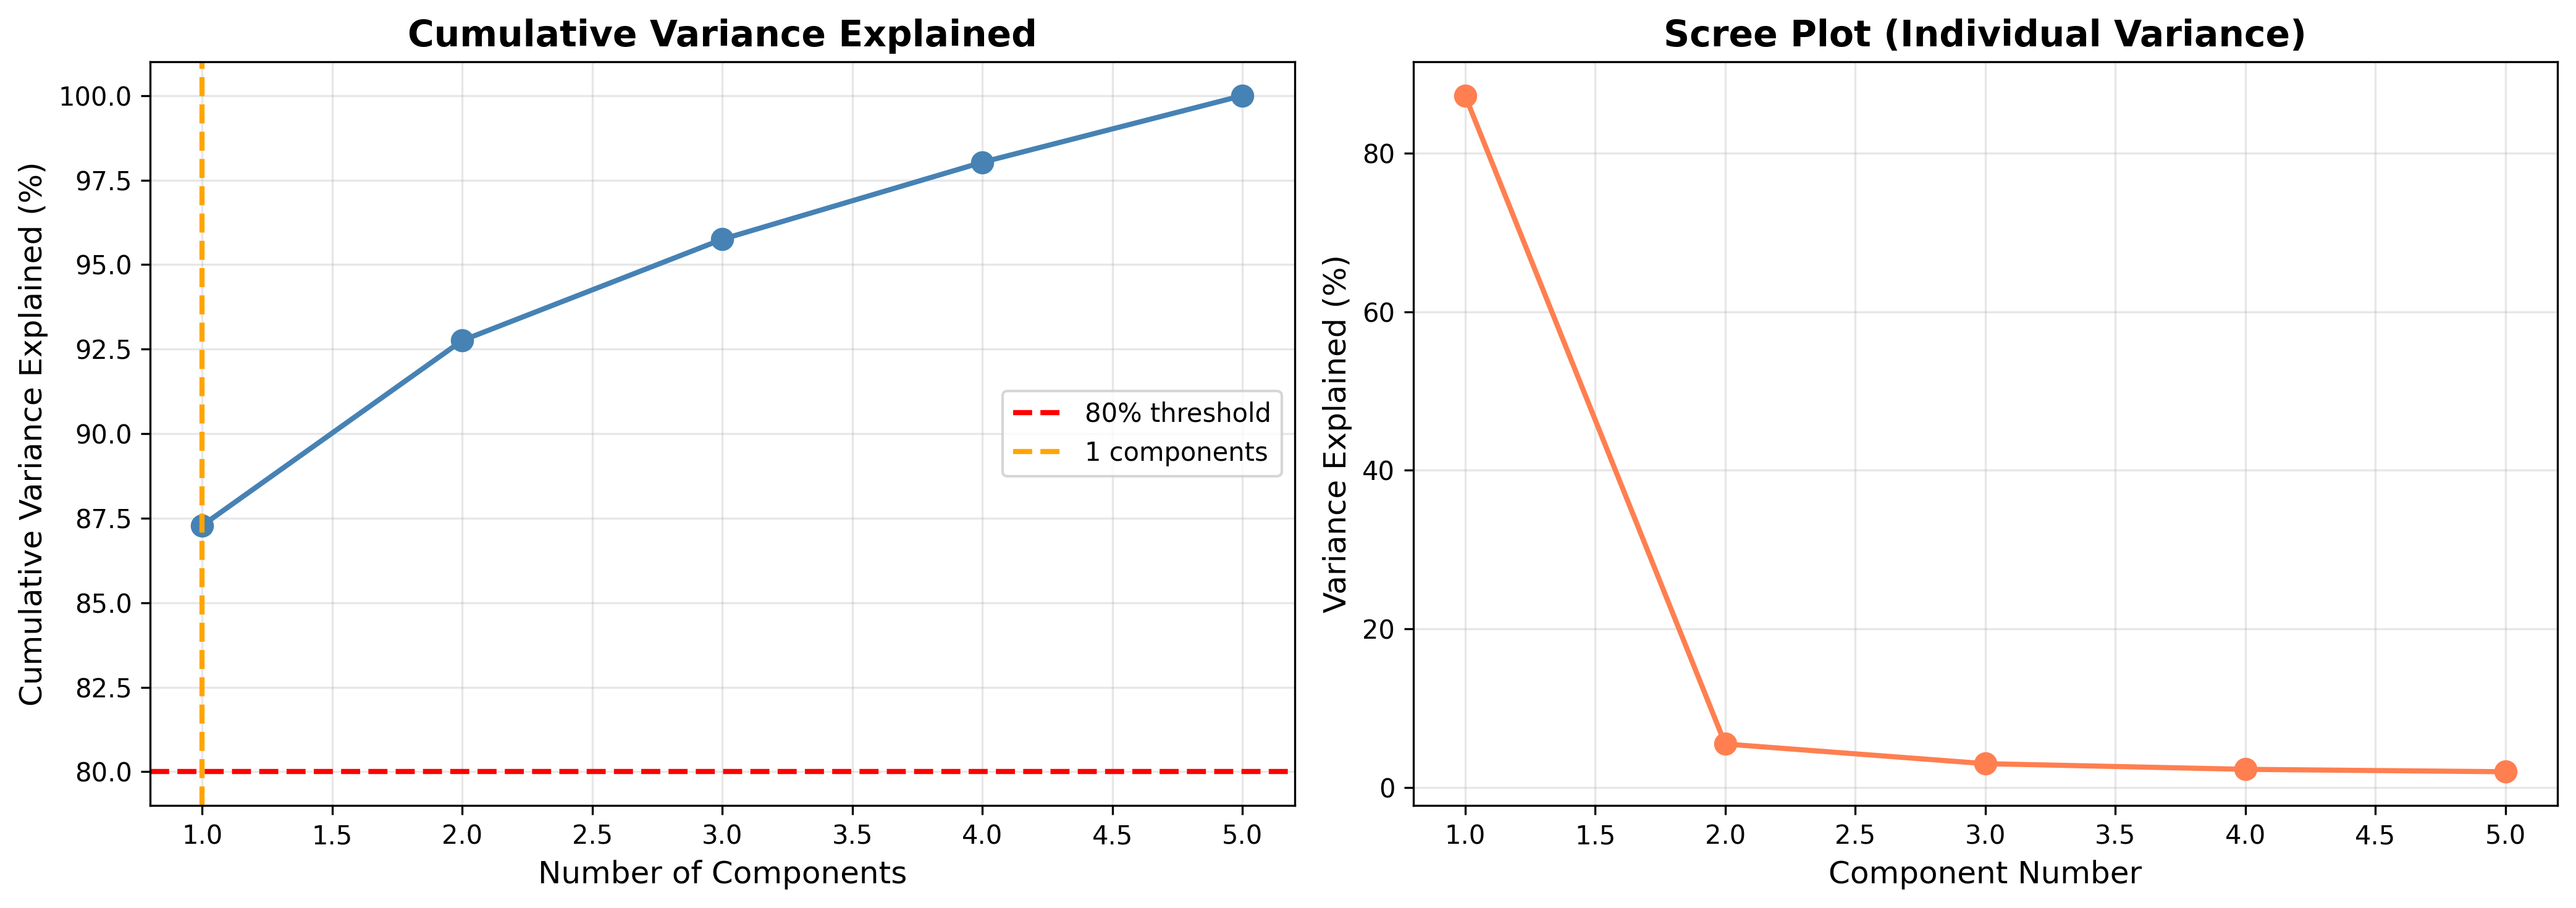

✓ Saved: pca_pc1_vs_pc2.png


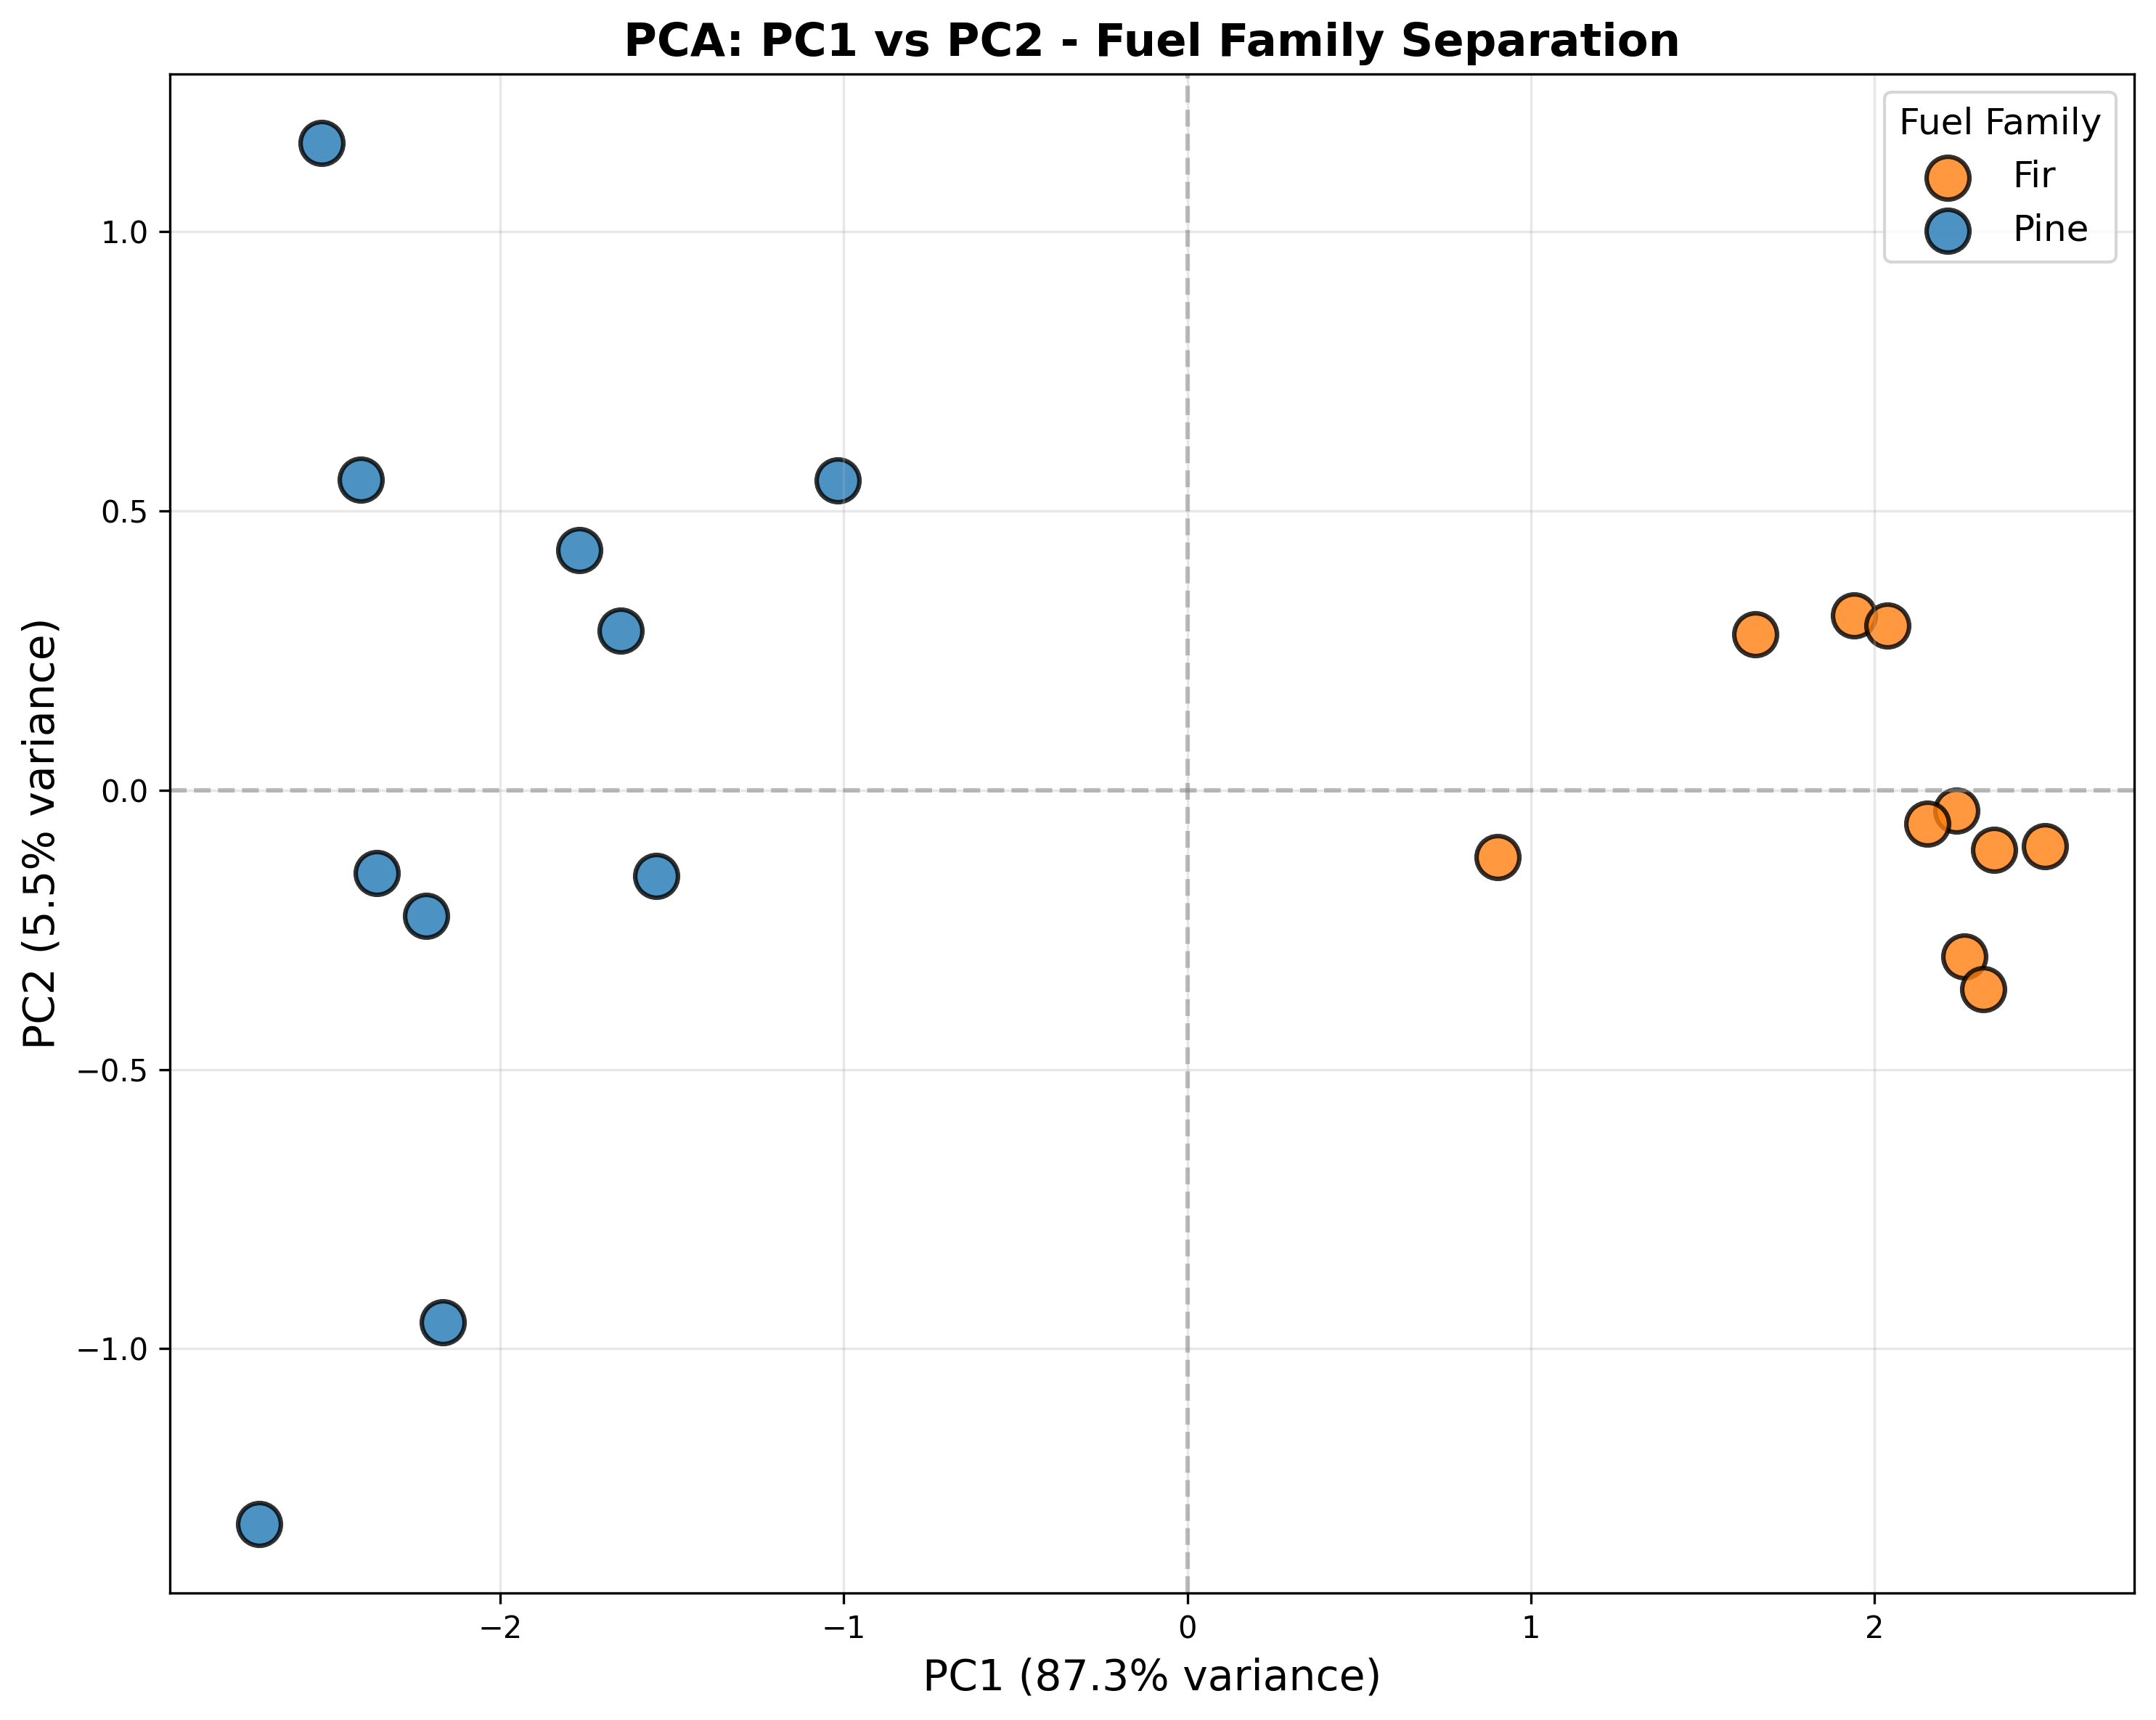

✓ Saved: pca_pc1_vs_pc4.png


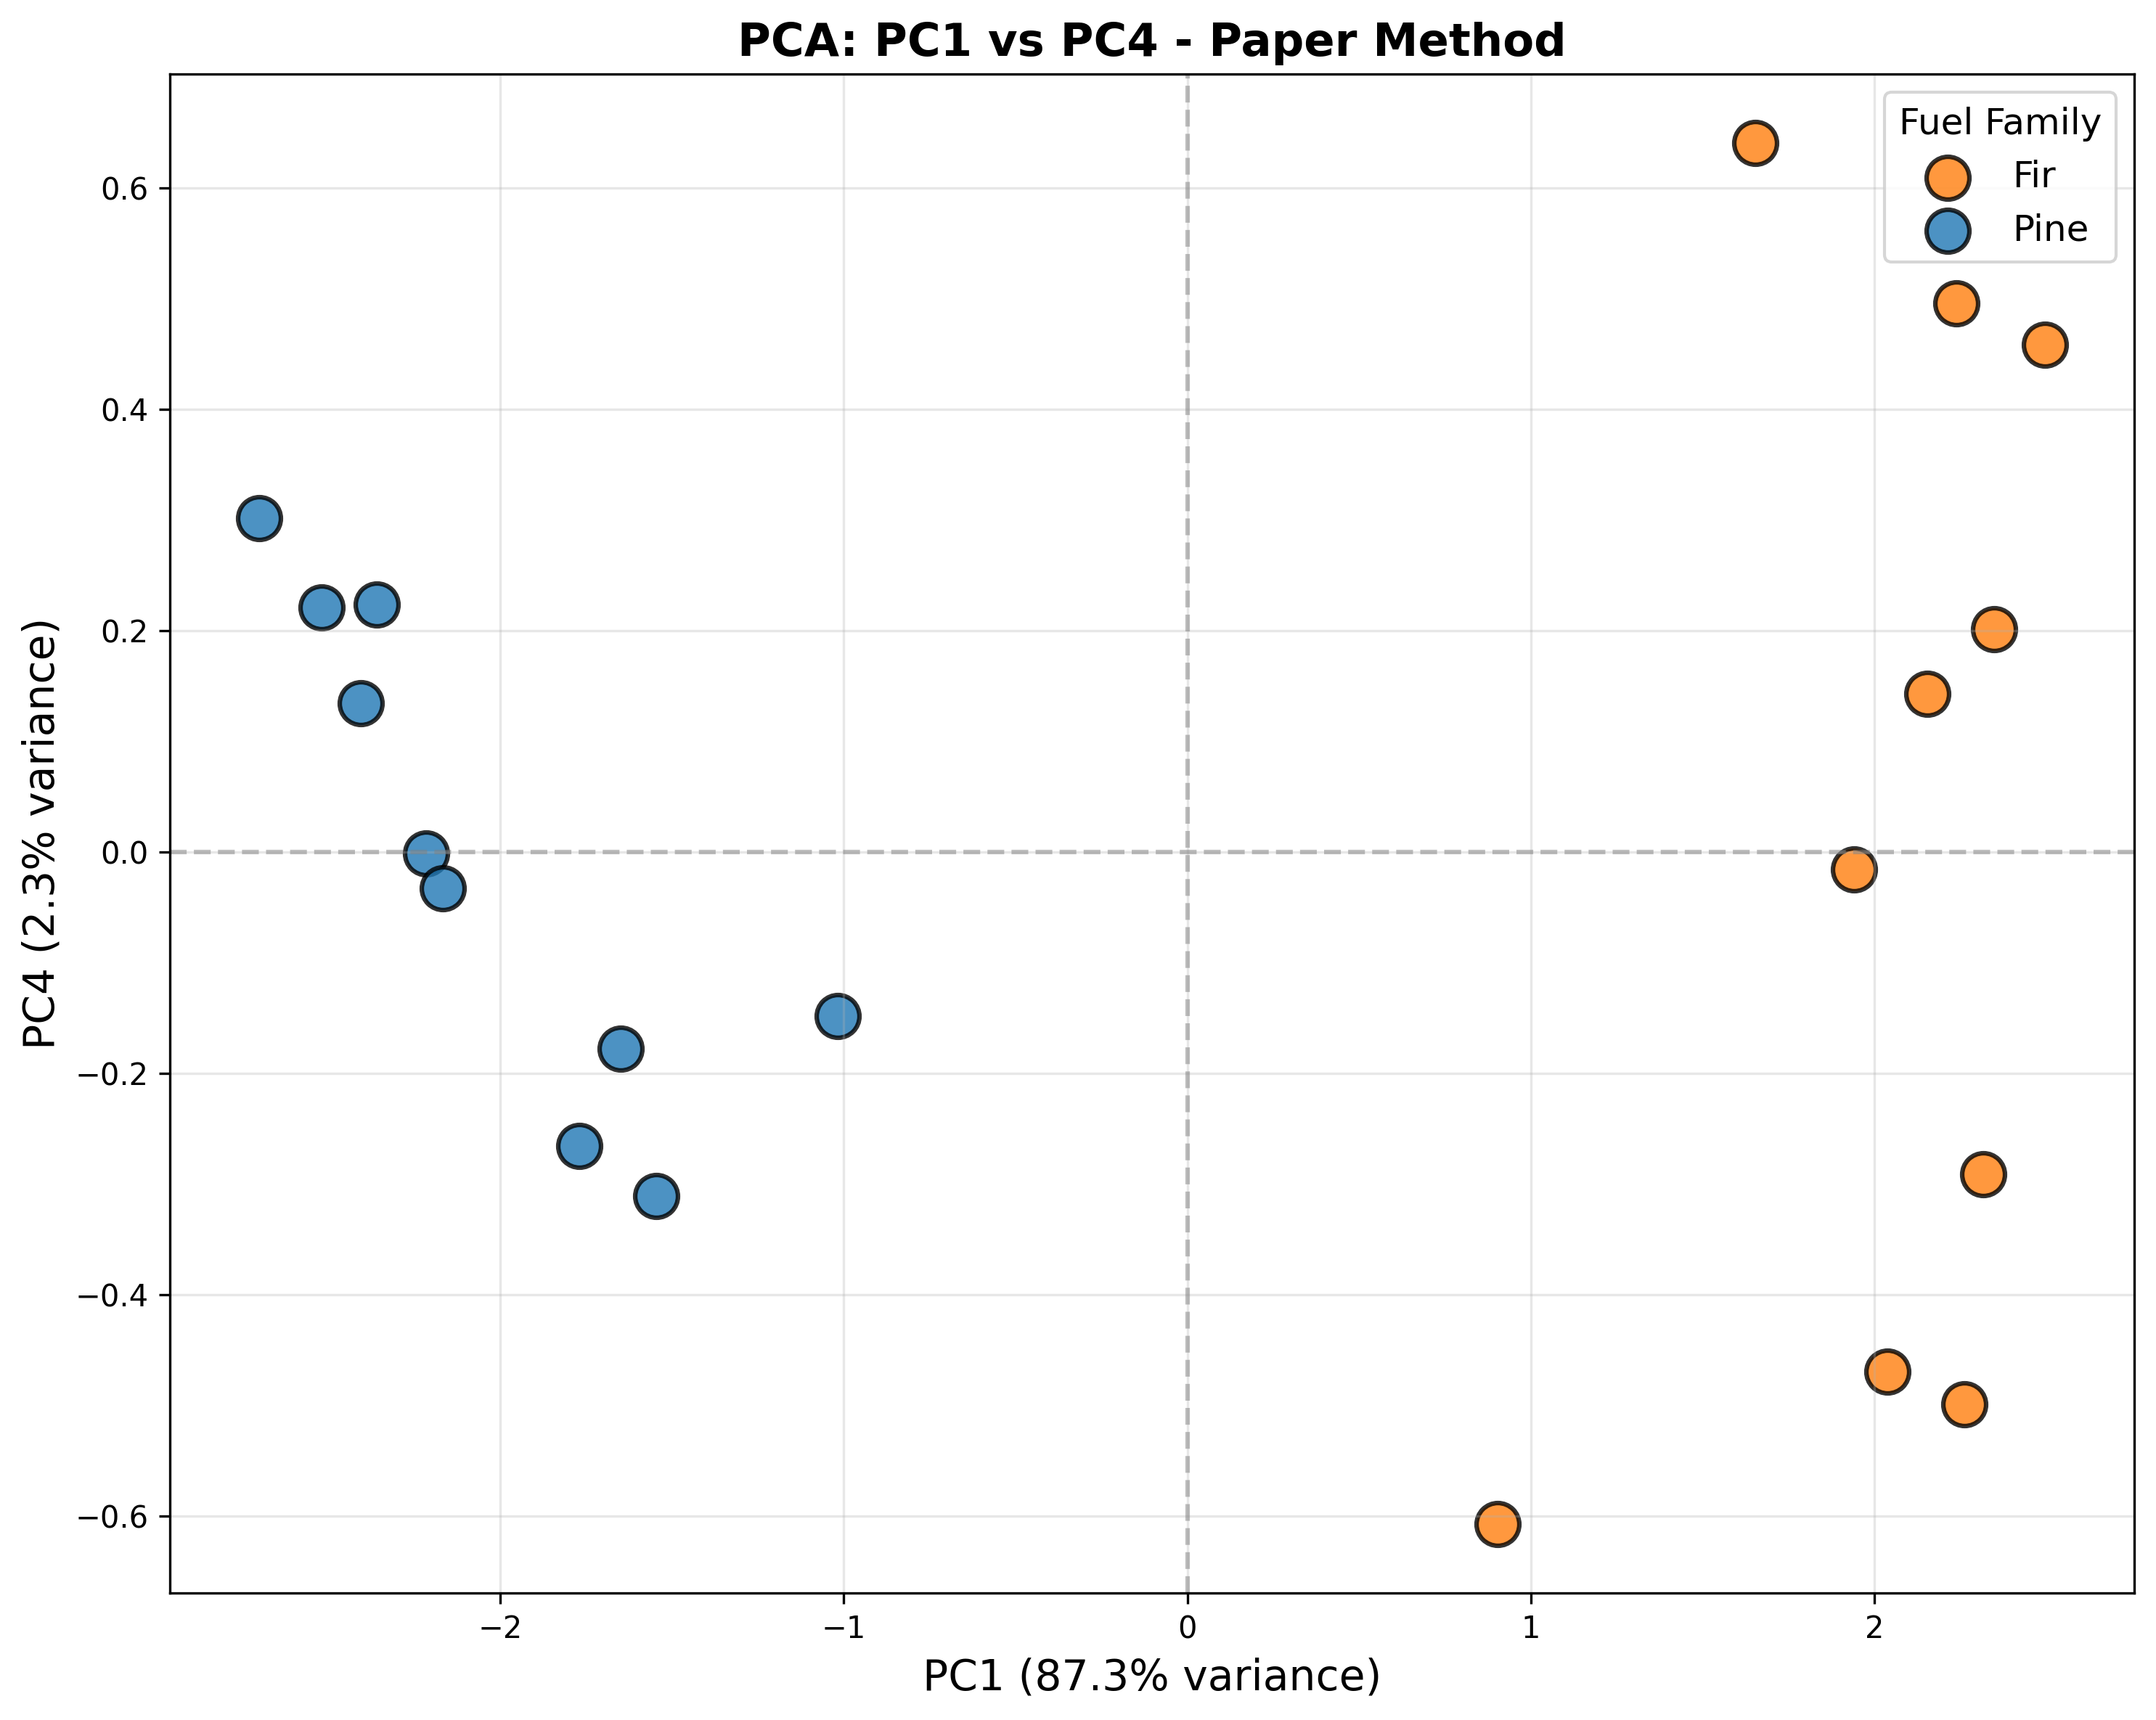


COMPONENT LOADINGS (Which compounds drive each PC)

PC1 (explains 87.3% variance):
  Top positive contributors:
    Camphene: +0.4580
    Tricyclene: +0.4569
    Myrtenal: +0.4512
  Top negative contributors:
    3-Carene: -0.4357
    beta-Pinene: -0.4337
    Myrtenal: +0.4512

PC2 (explains 5.5% variance):
  Top positive contributors:
    beta-Pinene: +0.7281
    Tricyclene: +0.0516
    Myrtenal: +0.0473
  Top negative contributors:
    3-Carene: -0.6796
    Camphene: -0.0551
    Myrtenal: +0.0473

PC3 (explains 3.0% variance):
  Top positive contributors:
    Myrtenal: +0.7683
    3-Carene: +0.4183
    beta-Pinene: +0.3015
  Top negative contributors:
    Camphene: -0.3021
    Tricyclene: +0.2292
    beta-Pinene: +0.3015

✓ Saved: pca_biplot.png


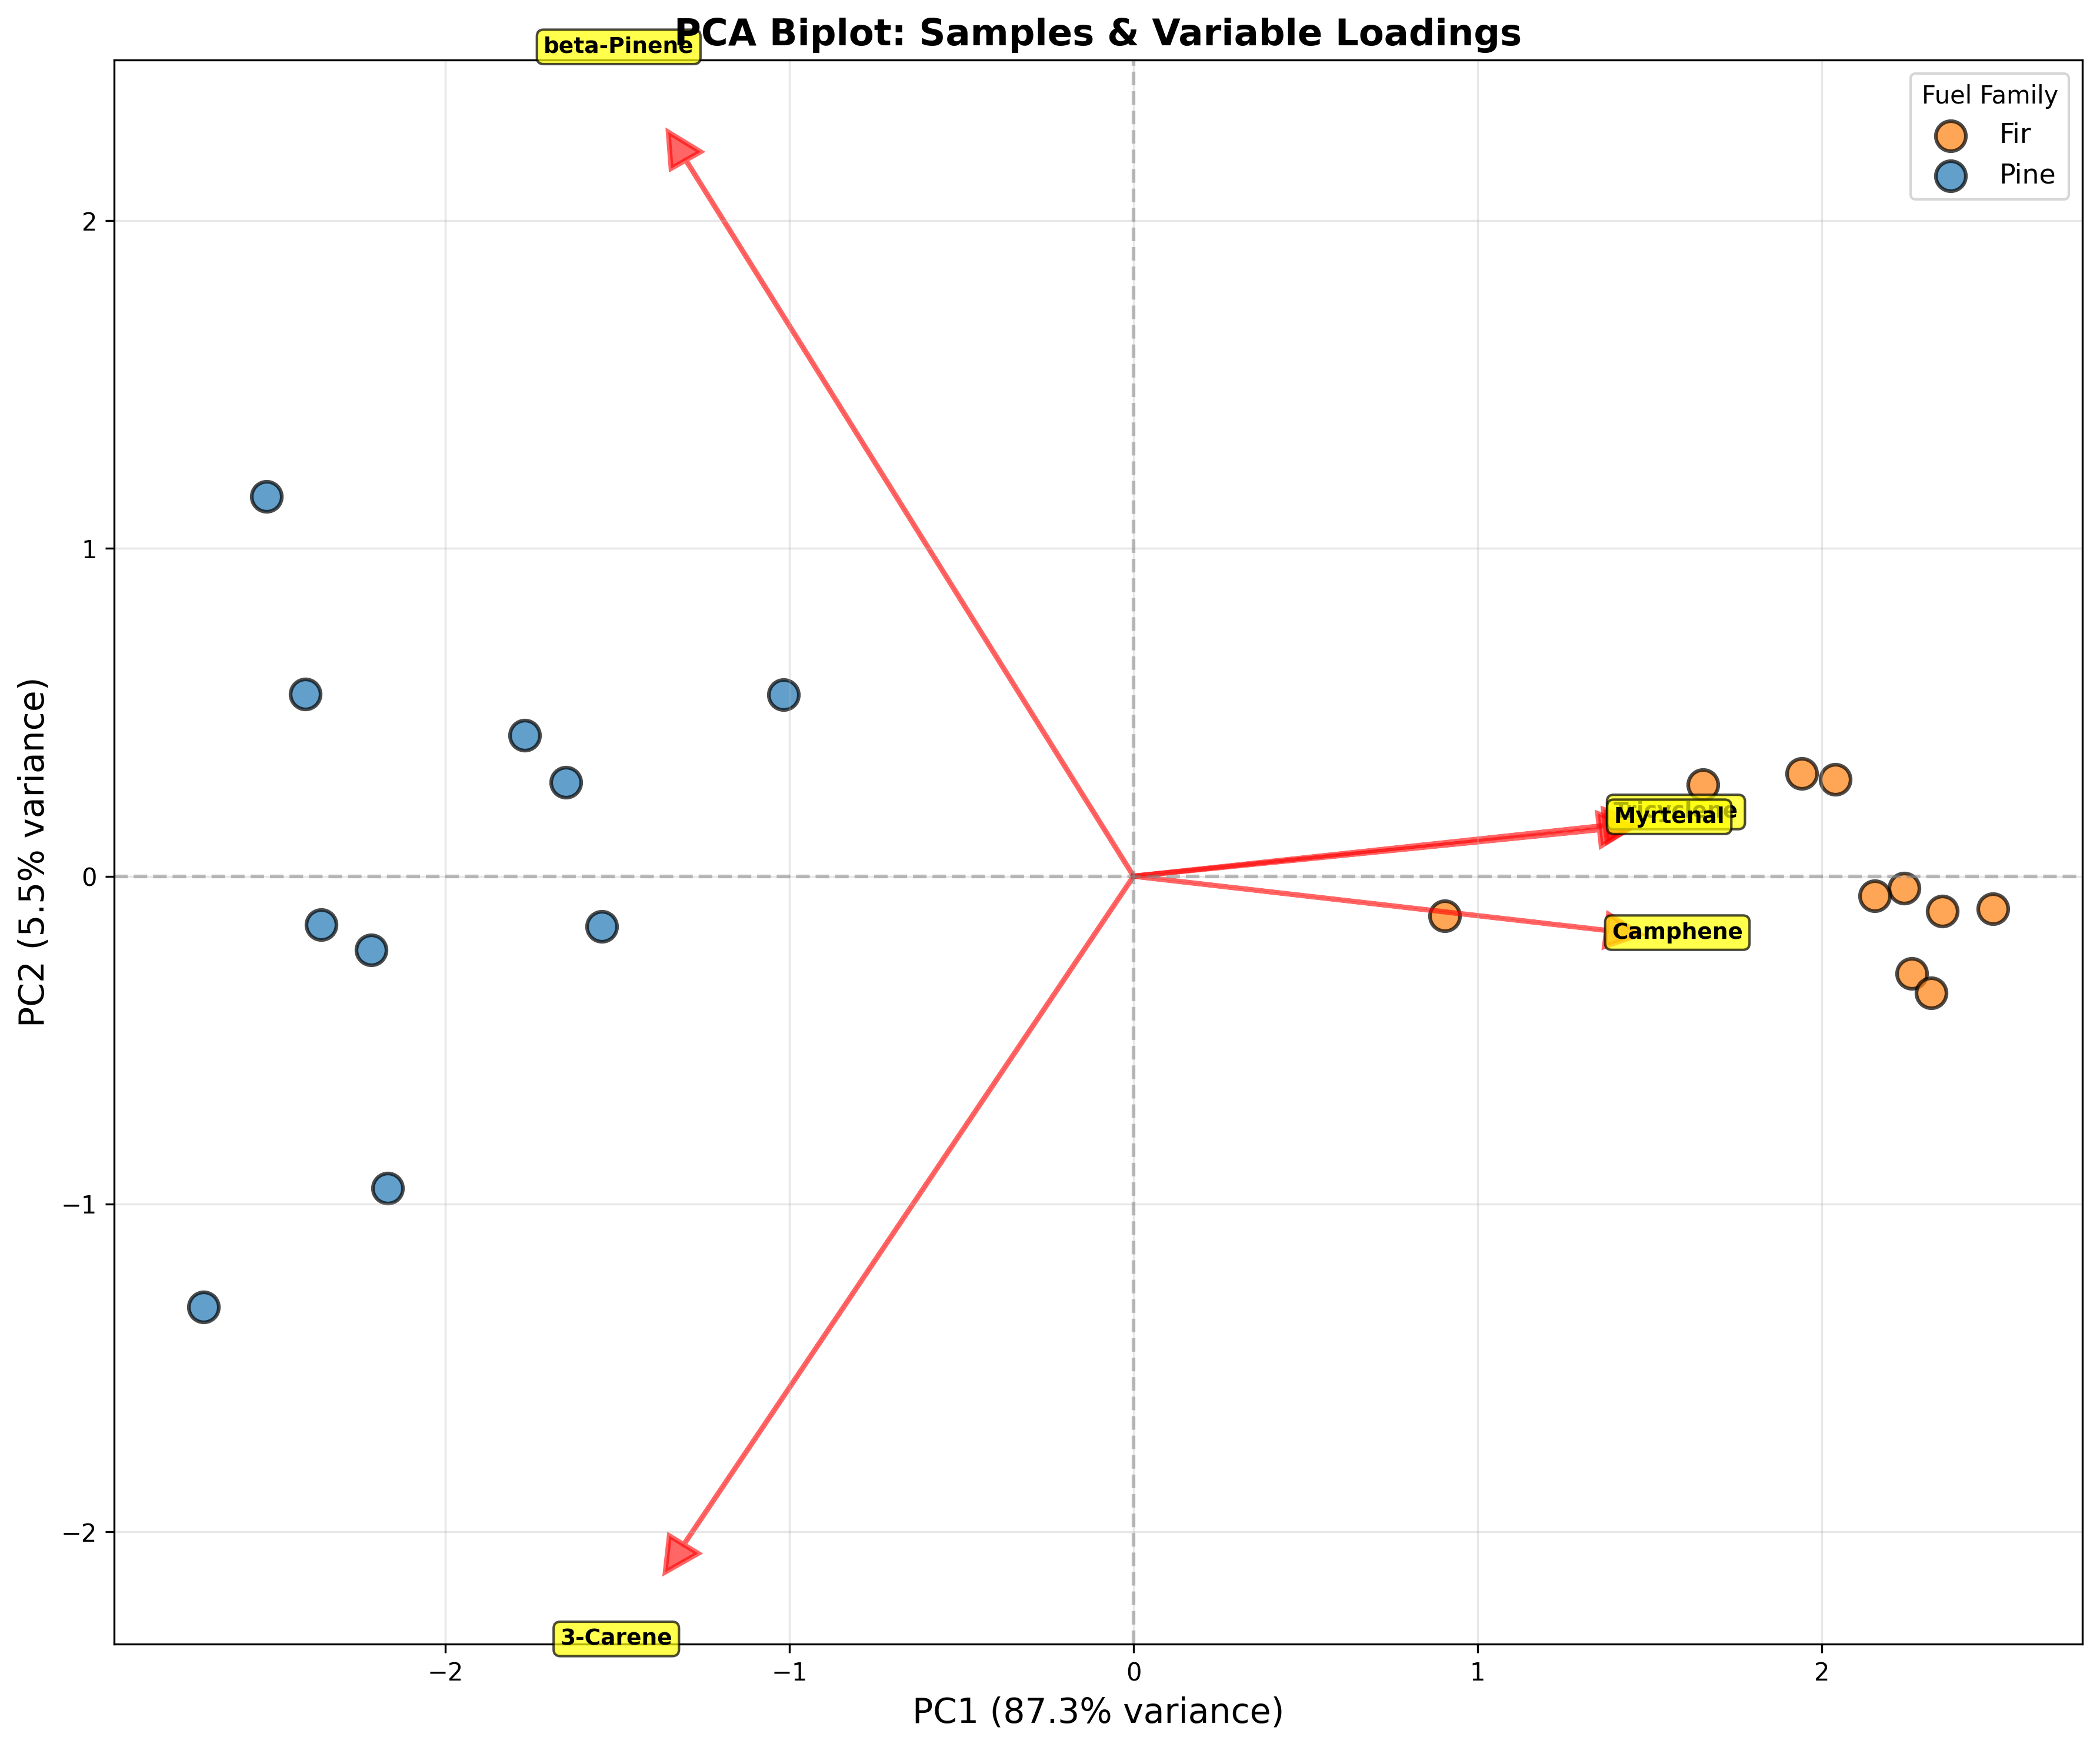


PCA COMPLETE!
✓ Total variance explained by PC1-PC1: 87.3%
✓ PC1 explains: 87.3%
✓ PC2 explains: 5.5%

✅ Variables created for next step:
   - X_pca: PCA scores ((20, 5))
   - pca_df: DataFrame with PC scores and labels
   - pca_full: Fitted PCA model

✅ NEXT STEP: K-Means Clustering on PCA scores


In [11]:
"""
PCA - PRINCIPAL COMPONENT ANALYSIS
Run this AFTER the feature selection code
Uses X_selected and y from previous step
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

plt.rcParams['figure.dpi'] = 300

# =============================================================================
# STEP 18: PCA ON SELECTED FEATURES
# =============================================================================
print("\n" + "="*80)
print("STEP 18: PRINCIPAL COMPONENT ANALYSIS")
print("="*80)

# X_selected and y already exist from the previous feature selection step
# X_selected is ALREADY STANDARDIZED (mean=0, std=1)

print(f"✓ Using selected features from memory")
print(f"  Feature matrix: {X_selected.shape}")
print(f"  Labels: {y.shape}")
print(f"  Already standardized: Yes")

# =============================================================================
# STEP 19: FIT PCA WITH ALL COMPONENTS
# =============================================================================
# First fit with all possible components to see variance explained

n_max_components = min(X_selected.shape[0], X_selected.shape[1])

pca_full = PCA(n_components=n_max_components)
pca_full.fit(X_selected)

# Calculate cumulative variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

# Find components needed for 80% variance (paper threshold)
n_components_80 = np.argmax(cumvar >= 80) + 1

print("\n" + "="*80)
print("VARIANCE EXPLAINED ANALYSIS")
print("="*80)
print(f"✓ Components for 80% variance: {n_components_80}")
print(f"\nVariance by component:")
for i in range(len(pca_full.explained_variance_ratio_)):
    var = pca_full.explained_variance_ratio_[i] * 100
    cumvar_i = cumvar[i]
    print(f"  PC{i+1}: {var:6.2f}%  (cumulative: {cumvar_i:6.2f}%)")

# =============================================================================
# STEP 20: TRANSFORM DATA TO PCA SPACE
# =============================================================================
# Get PCA scores for all components

X_pca = pca_full.transform(X_selected)

print(f"\n✓ PCA transformation complete")
print(f"  PCA scores shape: {X_pca.shape}")

# =============================================================================
# STEP 21: CREATE PCA RESULTS DATAFRAME
# =============================================================================

pca_df = pd.DataFrame(
    data=X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)
pca_df["Fuel_Family"] = y
pca_df["Sample_Name"] = df_cleaned['Burn_No'].values  # Or whatever ID column you have

print("\n" + "="*80)
print("PCA RESULTS DATAFRAME")
print("="*80)
print(pca_df.head())

# =============================================================================
# STEP 22: VISUALIZE VARIANCE EXPLAINED (SCREE PLOT)
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cumulative variance
ax1.plot(range(1, len(cumvar) + 1), cumvar, 'o-',
         linewidth=2, markersize=8, color='steelblue')
ax1.axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% threshold')
ax1.axvline(x=n_components_80, color='orange', linestyle='--',
            linewidth=2, label=f'{n_components_80} components')
ax1.set_xlabel('Number of Components', fontsize=12)
ax1.set_ylabel('Cumulative Variance Explained (%)', fontsize=12)
ax1.set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Scree plot
ax2.plot(range(1, len(cumvar) + 1),
         pca_full.explained_variance_ratio_ * 100,
         'o-', linewidth=2, markersize=8, color='coral')
ax2.set_xlabel('Component Number', fontsize=12)
ax2.set_ylabel('Variance Explained (%)', fontsize=12)
ax2.set_title('Scree Plot (Individual Variance)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_variance_explained.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: pca_variance_explained.png")
plt.show()

# =============================================================================
# STEP 23: VISUALIZE PC1 vs PC2 (MAIN PLOT)
# =============================================================================

plt.figure(figsize=(10, 8))

# Get unique fuel families and assign colors
fuel_families = np.unique(y)
colors = {'Pine': '#1f77b4', 'Fir': '#ff7f0e', 'Spruce': '#2ca02c', 'Shrub': '#d62728'}

# Plot each fuel family
for fuel in fuel_families:
    mask = pca_df['Fuel_Family'] == fuel
    plt.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        label=fuel,
        s=200,
        alpha=0.8,
        edgecolors='black',
        linewidths=1.5,
        color=colors.get(fuel, 'gray')
    )

# Formatting
var1 = pca_full.explained_variance_ratio_[0] * 100
var2 = pca_full.explained_variance_ratio_[1] * 100

plt.xlabel(f'PC1 ({var1:.1f}% variance)', fontsize=14)
plt.ylabel(f'PC2 ({var2:.1f}% variance)', fontsize=14)
plt.title('PCA: PC1 vs PC2 - Fuel Family Separation', fontsize=15, fontweight='bold')
plt.legend(title='Fuel Family', fontsize=12, title_fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('pca_pc1_vs_pc2.png', dpi=300, bbox_inches='tight')
print("✓ Saved: pca_pc1_vs_pc2.png")
plt.show()

# =============================================================================
# STEP 24: VISUALIZE PC1 vs PC4 (PAPER METHOD)
# =============================================================================
# Paper found better separation with PC1 vs PC4

if X_pca.shape[1] >= 4:
    plt.figure(figsize=(10, 8))

    for fuel in fuel_families:
        mask = pca_df['Fuel_Family'] == fuel
        plt.scatter(
            pca_df.loc[mask, 'PC1'],
            pca_df.loc[mask, 'PC4'],
            label=fuel,
            s=200,
            alpha=0.8,
            edgecolors='black',
            linewidths=1.5,
            color=colors.get(fuel, 'gray')
        )

    var1 = pca_full.explained_variance_ratio_[0] * 100
    var4 = pca_full.explained_variance_ratio_[3] * 100

    plt.xlabel(f'PC1 ({var1:.1f}% variance)', fontsize=14)
    plt.ylabel(f'PC4 ({var4:.1f}% variance)', fontsize=14)
    plt.title('PCA: PC1 vs PC4 - Paper Method', fontsize=15, fontweight='bold')
    plt.legend(title='Fuel Family', fontsize=12, title_fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('pca_pc1_vs_pc4.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: pca_pc1_vs_pc4.png")
    plt.show()
else:
    print("\n⚠️ Not enough components for PC1 vs PC4 plot")

# =============================================================================
# STEP 25: ANALYZE COMPONENT LOADINGS
# =============================================================================
# Which compounds drive each PC?

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])],
    index=top_compounds  # Use the compound names we selected
)

print("\n" + "="*80)
print("COMPONENT LOADINGS (Which compounds drive each PC)")
print("="*80)

for i in range(min(3, X_pca.shape[1])):  # Show first 3 PCs
    pc = f'PC{i+1}'
    print(f"\n{pc} (explains {pca_full.explained_variance_ratio_[i]*100:.1f}% variance):")
    print(f"  Top positive contributors:")
    top_pos = loadings[pc].nlargest(3)
    for comp, val in top_pos.items():
        print(f"    {comp}: {val:+.4f}")

    print(f"  Top negative contributors:")
    top_neg = loadings[pc].nsmallest(3)
    for comp, val in top_neg.items():
        print(f"    {comp}: {val:+.4f}")

# =============================================================================
# STEP 26: BIPLOT (OPTIONAL - SHOWS SAMPLES + LOADINGS)
# =============================================================================

if X_pca.shape[1] >= 2:
    fig, ax = plt.subplots(figsize=(12, 10))

    # Plot samples
    for fuel in fuel_families:
        mask = pca_df['Fuel_Family'] == fuel
        ax.scatter(
            pca_df.loc[mask, 'PC1'],
            pca_df.loc[mask, 'PC2'],
            label=fuel,
            s=150,
            alpha=0.7,
            edgecolors='black',
            linewidths=1.5,
            color=colors.get(fuel, 'gray')
        )

    # Plot loading vectors
    scale_factor = 3  # Adjust to make arrows visible
    for i, compound in enumerate(top_compounds):
        ax.arrow(0, 0,
                loadings.loc[compound, 'PC1'] * scale_factor,
                loadings.loc[compound, 'PC2'] * scale_factor,
                head_width=0.1, head_length=0.1,
                fc='red', ec='red', alpha=0.6, linewidth=2)

        # Label the arrow
        ax.text(loadings.loc[compound, 'PC1'] * scale_factor * 1.15,
               loadings.loc[compound, 'PC2'] * scale_factor * 1.15,
               compound[:20],  # Truncate long names
               fontsize=9, ha='center', weight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

    var1 = pca_full.explained_variance_ratio_[0] * 100
    var2 = pca_full.explained_variance_ratio_[1] * 100

    ax.set_xlabel(f'PC1 ({var1:.1f}% variance)', fontsize=14)
    ax.set_ylabel(f'PC2 ({var2:.1f}% variance)', fontsize=14)
    ax.set_title('PCA Biplot: Samples & Variable Loadings', fontsize=15, fontweight='bold')
    ax.legend(title='Fuel Family', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('pca_biplot.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: pca_biplot.png")
    plt.show()

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "="*80)
print("PCA COMPLETE!")
print("="*80)
print(f"✓ Total variance explained by PC1-PC{n_components_80}: {cumvar[n_components_80-1]:.1f}%")
print(f"✓ PC1 explains: {pca_full.explained_variance_ratio_[0]*100:.1f}%")
print(f"✓ PC2 explains: {pca_full.explained_variance_ratio_[1]*100:.1f}%")

print(f"\n✅ Variables created for next step:")
print(f"   - X_pca: PCA scores ({X_pca.shape})")
print(f"   - pca_df: DataFrame with PC scores and labels")
print(f"   - pca_full: Fitted PCA model")

print(f"\n✅ NEXT STEP: K-Means Clustering on PCA scores")


K-MEANS CLUSTERING
✓ Using PC1 and PC2 for clustering
  Samples: 20
  Fuel families: ['Fir' 'Pine']
  Number of fuel families: 2

ELBOW METHOD
Testing k from 1 to 10...

  k=1: TWSS = 92.76
  k=2: TWSS = 9.87
  k=3: TWSS = 6.08
  k=4: TWSS = 4.39
  k=5: TWSS = 2.96
  k=6: TWSS = 2.04
  k=7: TWSS = 1.26
  k=8: TWSS = 0.86
  k=9: TWSS = 0.65
  k=10: TWSS = 0.46

✓ Expected optimal k: 2 (number of fuel families)

✓ Saved: kmeans_elbow_plot.png


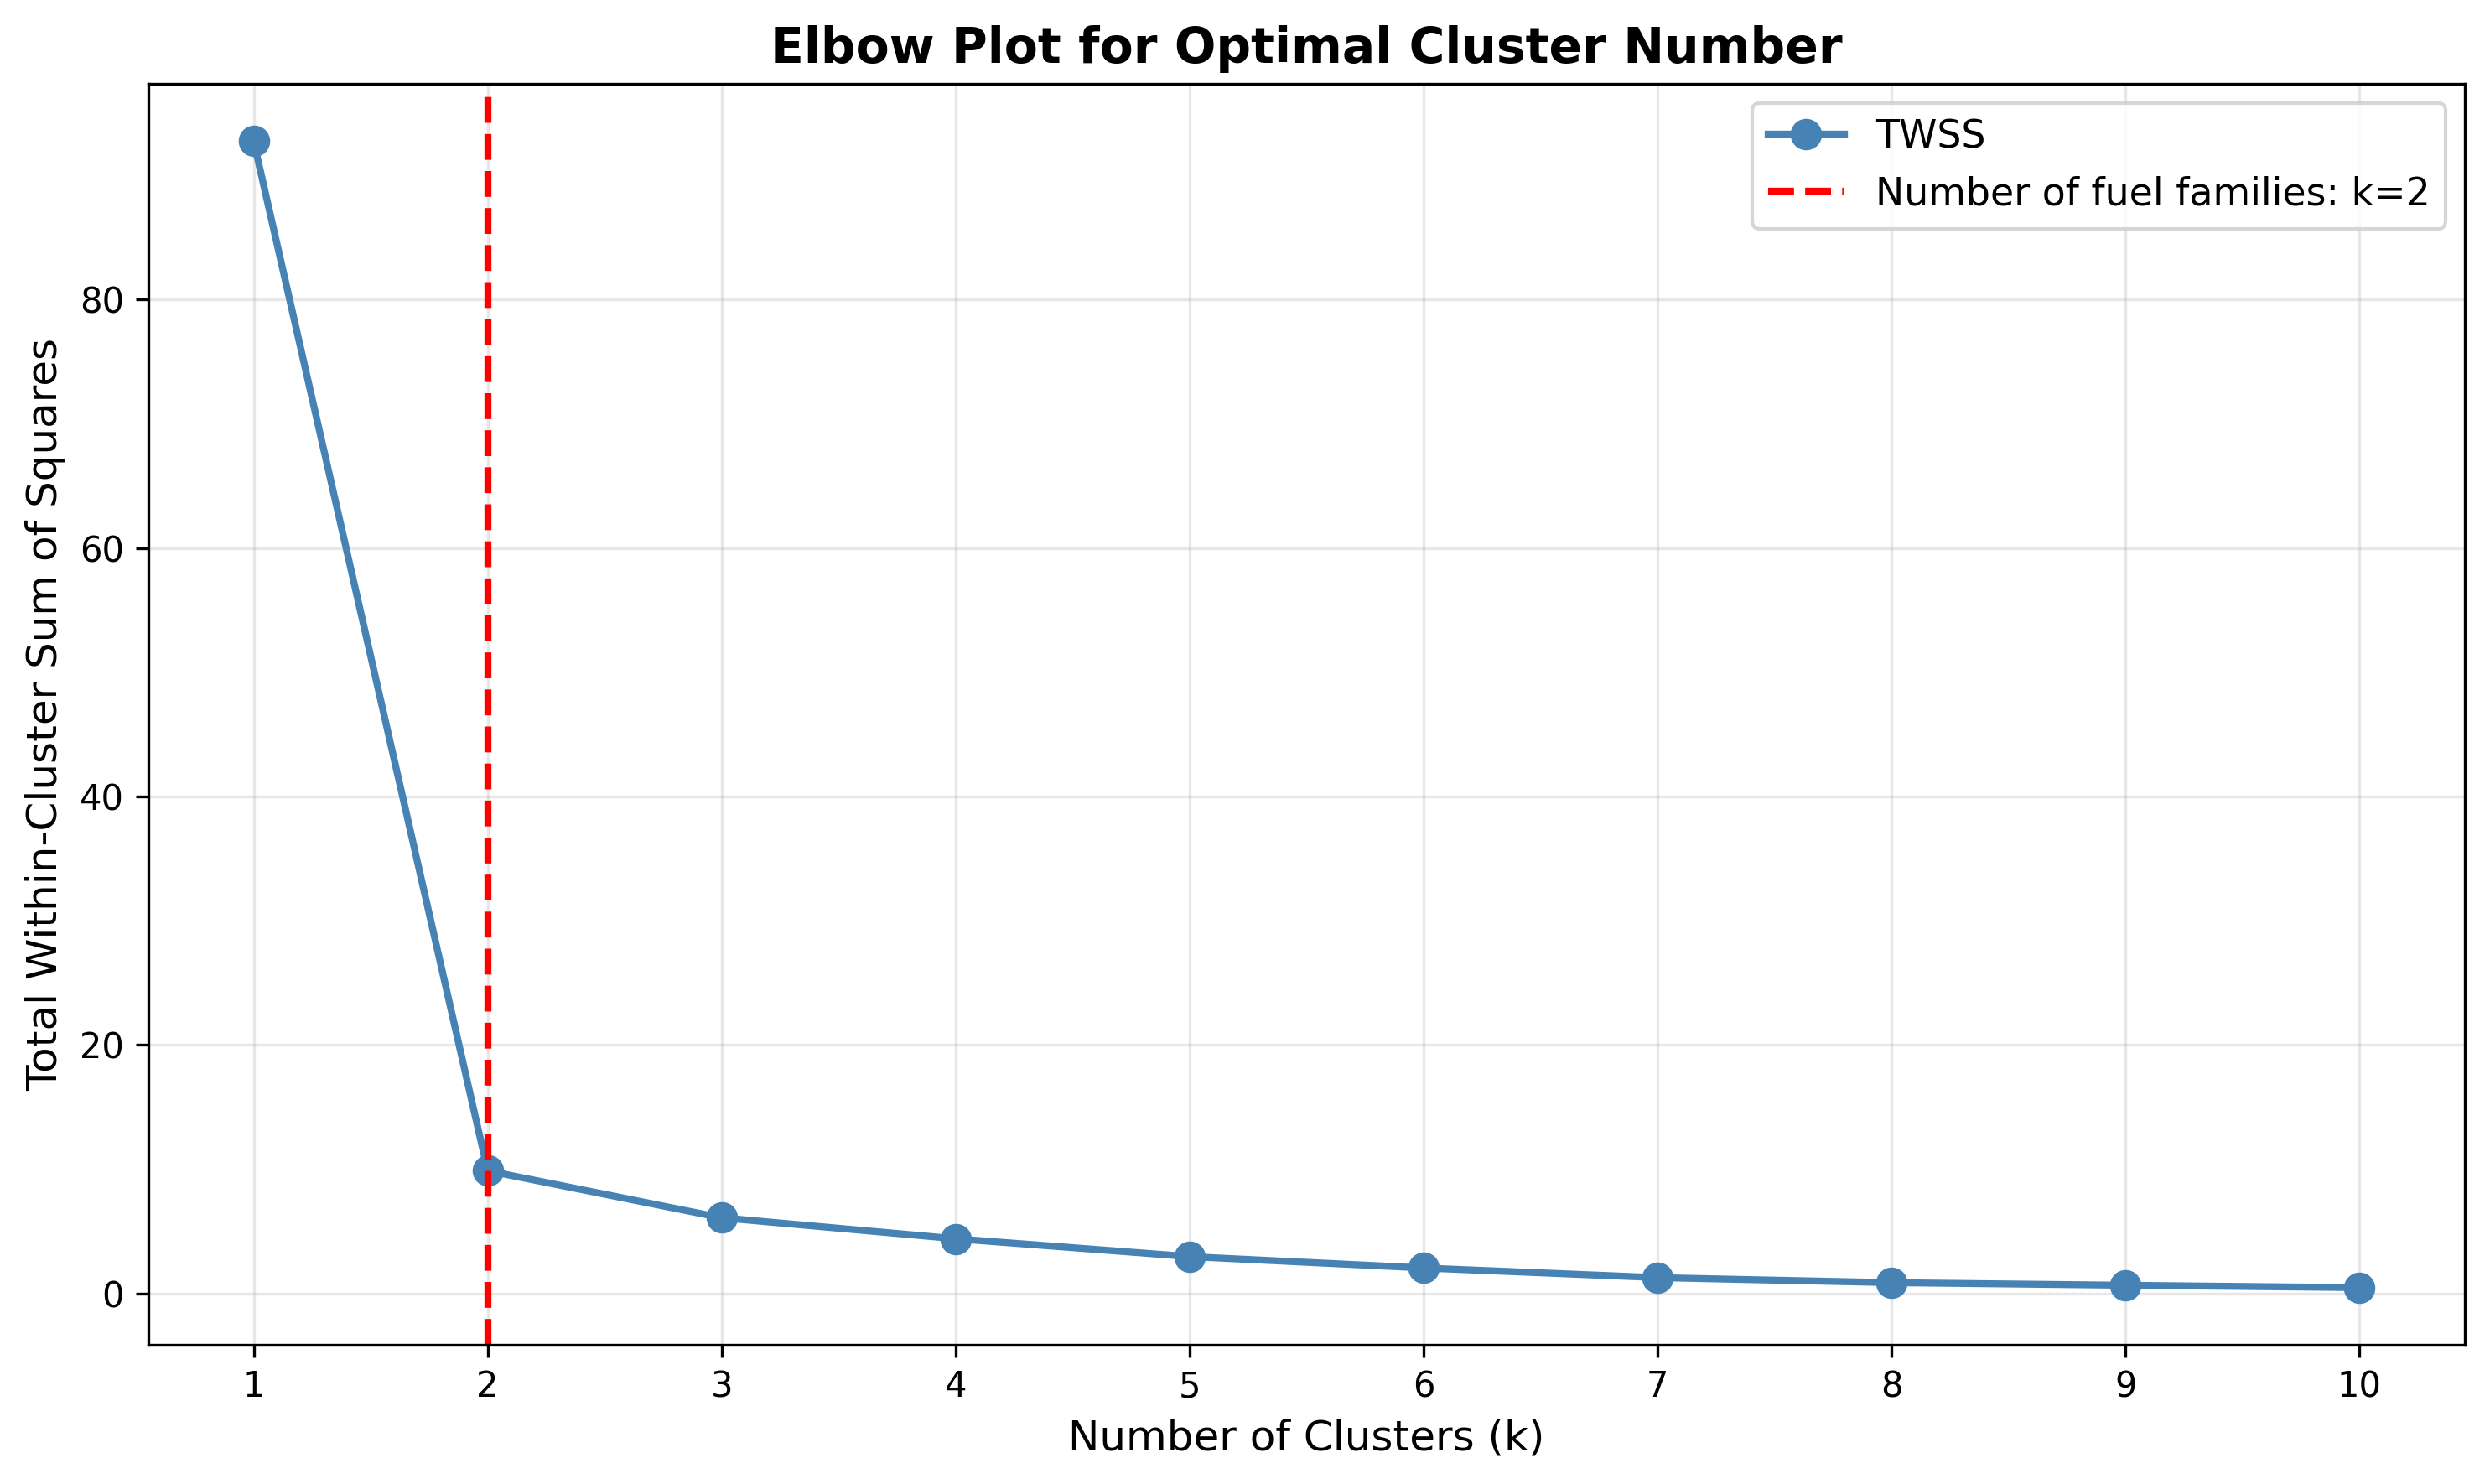


CLUSTERING WITH k=2

✓ K-means fitted
  Cluster centers: (2, 2)
  Inertia (TWSS): 9.87
  Silhouette score: 0.780 (closer to 1 = better)

CLUSTER COMPOSITION

Cluster 1 (10 samples):
  Pine: 10 samples

Cluster 2 (10 samples):
  Fir: 10 samples

CONFUSION MATRIX (Fuel Family vs Cluster)
Cluster       1   2
Fuel Family        
Fir           0  10
Pine         10   0

✓ Saved: kmeans_clustering.png


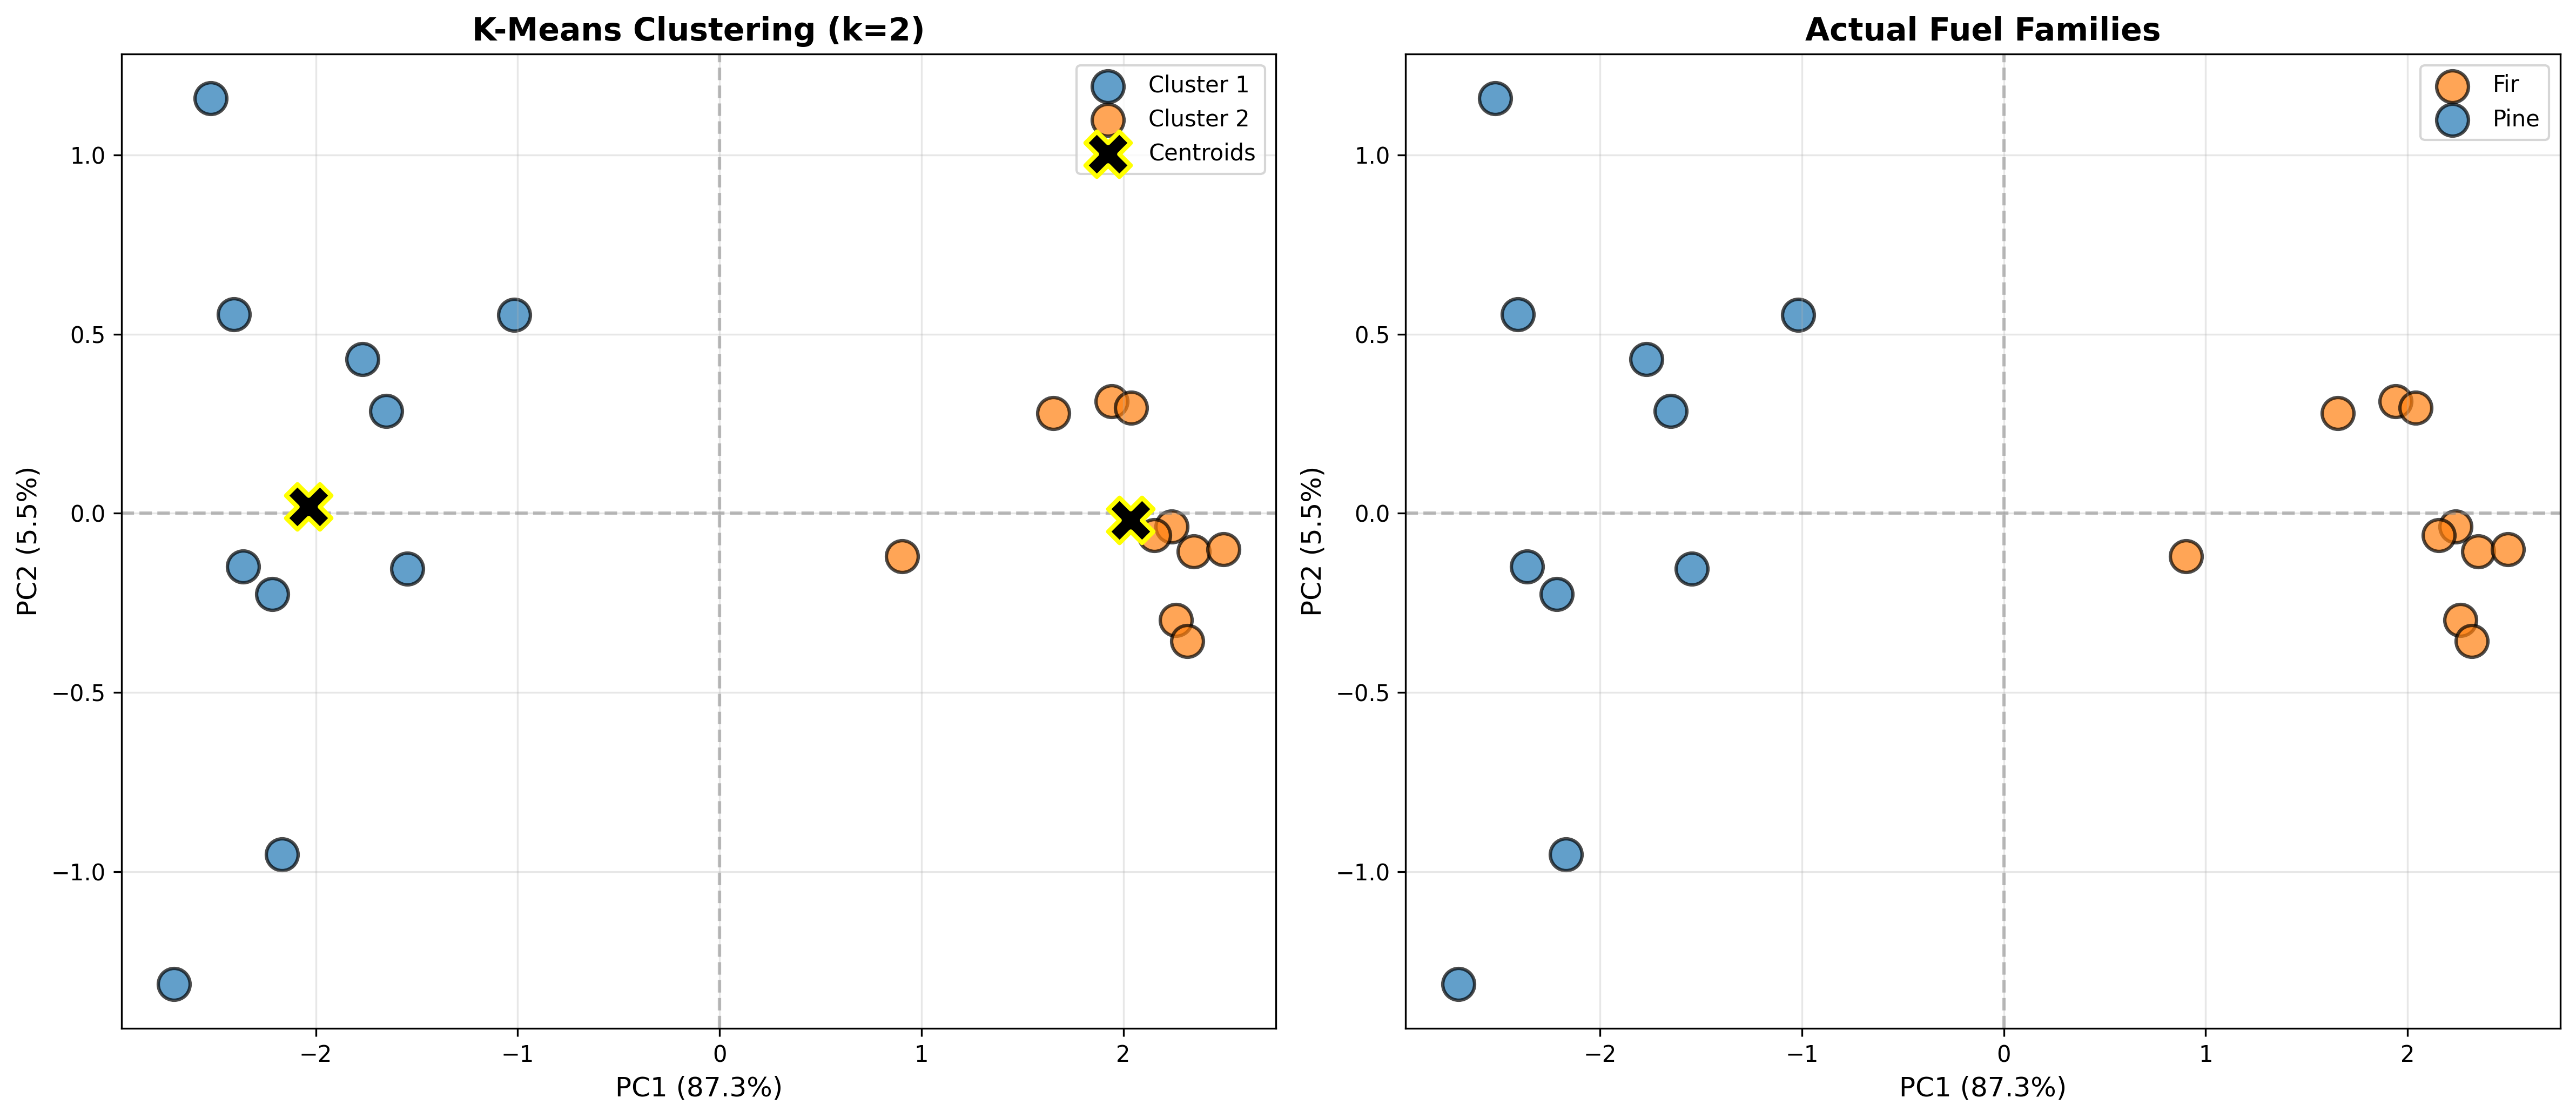


K-MEANS CLUSTERING COMPLETE!
✓ Optimal k: 2
✓ TWSS: 9.87
✓ Silhouette score: 0.780

✅ Variables created for next step:
   - cluster_labels: cluster assignments for each sample
   - kmeans_final: fitted k-means model

✅ NEXT STEP: LDA Classification


In [14]:
"""
K-MEANS CLUSTERING
Run this AFTER PCA
Uses X_pca and y from previous steps
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.rcParams['figure.dpi'] = 300

# =============================================================================
# K-MEANS CLUSTERING ON PCA SCORES
# =============================================================================
print("\n" + "="*80)
print("K-MEANS CLUSTERING")
print("="*80)

# Use PC1 and PC2 for clustering (from previous PCA step)
X_cluster = X_pca[:, [0, 1]]  # PC1 and PC2

print(f"✓ Using PC1 and PC2 for clustering")
print(f"  Samples: {X_cluster.shape[0]}")
print(f"  Fuel families: {np.unique(y)}")
print(f"  Number of fuel families: {len(np.unique(y))}")

# =============================================================================
# ELBOW METHOD - FIND OPTIMAL K
# =============================================================================
print("\n" + "="*80)
print("ELBOW METHOD")
print("="*80)

k_max = min(10, X_cluster.shape[0])
twss = []  # Total within-cluster sum of squares

print(f"Testing k from 1 to {k_max}...\n")
for k in range(1, k_max + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    twss.append(kmeans.inertia_)
    print(f"  k={k}: TWSS = {kmeans.inertia_:.2f}")

# Expected k = number of fuel families
n_fuel_families = len(np.unique(y))
print(f"\n✓ Expected optimal k: {n_fuel_families} (number of fuel families)")

# =============================================================================
# VISUALIZE ELBOW PLOT
# =============================================================================

plt.figure(figsize=(10, 6))

plt.plot(range(1, k_max + 1), twss, 'o-', linewidth=2, markersize=8,
         color='steelblue', label='TWSS')

# Mark the expected k
plt.axvline(x=n_fuel_families, color='red', linestyle='--', linewidth=2,
            label=f'Number of fuel families: k={n_fuel_families}')

plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Total Within-Cluster Sum of Squares', fontsize=12)
plt.title('Elbow Plot for Optimal Cluster Number', fontsize=14, fontweight='bold')
plt.xticks(range(1, k_max + 1))
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('kmeans_elbow_plot.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: kmeans_elbow_plot.png")
plt.show()

# =============================================================================
# PERFORM K-MEANS WITH OPTIMAL K
# =============================================================================
print("\n" + "="*80)
print(f"CLUSTERING WITH k={n_fuel_families}")
print("="*80)

optimal_k = n_fuel_families

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster)

print(f"\n✓ K-means fitted")
print(f"  Cluster centers: {kmeans_final.cluster_centers_.shape}")
print(f"  Inertia (TWSS): {kmeans_final.inertia_:.2f}")

# Calculate silhouette score (quality metric)
if optimal_k > 1:
    silhouette = silhouette_score(X_cluster, cluster_labels)
    print(f"  Silhouette score: {silhouette:.3f} (closer to 1 = better)")

# =============================================================================
# ANALYZE CLUSTER COMPOSITION
# =============================================================================
print("\n" + "="*80)
print("CLUSTER COMPOSITION")
print("="*80)

for cluster_id in range(optimal_k):
    mask = cluster_labels == cluster_id
    fuels_in_cluster = y[mask]

    print(f"\nCluster {cluster_id + 1} ({mask.sum()} samples):")
    unique, counts = np.unique(fuels_in_cluster, return_counts=True)
    for fuel, count in zip(unique, counts):
        print(f"  {fuel}: {count} samples")

# =============================================================================
# CONFUSION MATRIX
# =============================================================================
print("\n" + "="*80)
print("CONFUSION MATRIX (Fuel Family vs Cluster)")
print("="*80)

confusion = pd.crosstab(
    y,
    cluster_labels + 1,  # +1 for 1-indexed clusters
    rownames=['Fuel Family'],
    colnames=['Cluster']
)
print(confusion)

# =============================================================================
# VISUALIZE CLUSTERING RESULTS
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

colors_cluster = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
colors_fuel = {'Pine': '#1f77b4', 'Fir': '#ff7f0e', 'Spruce': '#2ca02c'}

# Get variance explained from previous PCA step
# FIXED: Use pca_full instead of pca
var1 = pca_full.explained_variance_ratio_[0] * 100
var2 = pca_full.explained_variance_ratio_[1] * 100

# Plot 1: Colored by K-means cluster assignment
for cluster_id in range(optimal_k):
    mask = cluster_labels == cluster_id
    ax1.scatter(
        X_cluster[mask, 0],  # PC1
        X_cluster[mask, 1],  # PC2
        label=f'Cluster {cluster_id + 1}',
        s=200,
        alpha=0.7,
        edgecolors='black',
        linewidths=1.5,
        color=colors_cluster[cluster_id]
    )

# Add cluster centers
ax1.scatter(
    kmeans_final.cluster_centers_[:, 0],
    kmeans_final.cluster_centers_[:, 1],
    c='black',
    marker='X',
    s=400,
    linewidths=2,
    edgecolors='yellow',
    label='Centroids',
    zorder=10
)

ax1.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=12)
ax1.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=12)
ax1.set_title(f'K-Means Clustering (k={optimal_k})', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# Plot 2: Colored by actual fuel family (for comparison)
for fuel in np.unique(y):
    mask = (y == fuel)
    ax2.scatter(
        X_cluster[mask, 0],  # PC1
        X_cluster[mask, 1],  # PC2
        label=fuel,
        s=200,
        alpha=0.7,
        edgecolors='black',
        linewidths=1.5,
        color=colors_fuel.get(fuel, 'gray')
    )

ax2.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=12)
ax2.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=12)
ax2.set_title('Actual Fuel Families', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('kmeans_clustering.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: kmeans_clustering.png")
plt.show()

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "="*80)
print("K-MEANS CLUSTERING COMPLETE!")
print("="*80)
print(f"✓ Optimal k: {optimal_k}")
print(f"✓ TWSS: {kmeans_final.inertia_:.2f}")
if optimal_k > 1:
    print(f"✓ Silhouette score: {silhouette:.3f}")

print(f"\n✅ Variables created for next step:")
print(f"   - cluster_labels: cluster assignments for each sample")
print(f"   - kmeans_final: fitted k-means model")

print(f"\n✅ NEXT STEP: LDA Classification")


LINEAR DISCRIMINANT ANALYSIS (LDA)
✓ Using PC1 and PC2 for LDA
  Features: (20, 2)
  Labels: (20,)
  Fuel families: ['Fir' 'Pine']

TRAIN/TEST SPLIT (70/30)
✓ Data split:
  Training: 14 samples
  Testing:  6 samples

Training set distribution:
  Fir: 7 samples
  Pine: 7 samples

Test set distribution:
  Fir: 3 samples
  Pine: 3 samples

TRAINING LDA MODEL
✓ LDA model trained
  Number of classes: 2
  Classes: ['Fir' 'Pine']

MODEL EVALUATION
Training accuracy: 100.0%
Test accuracy: 100.0%

PREDICTIONS ON ALL DATA

Sample predictions:
   Sample True_Fuel Predicted_Fuel  Fir_Probability_%  Pine_Probability_%
0  burn11       Fir            Fir       1.000000e+02        3.621904e-17
1  burn14       Fir            Fir       1.000000e+02        8.525687e-17
2  burn18       Fir            Fir       1.000000e+02        2.755098e-18
3  burn45       Fir            Fir       1.000000e+02        3.351268e-16
4  burn57       Fir            Fir       1.000000e+02        2.567175e-17
5  burn64       

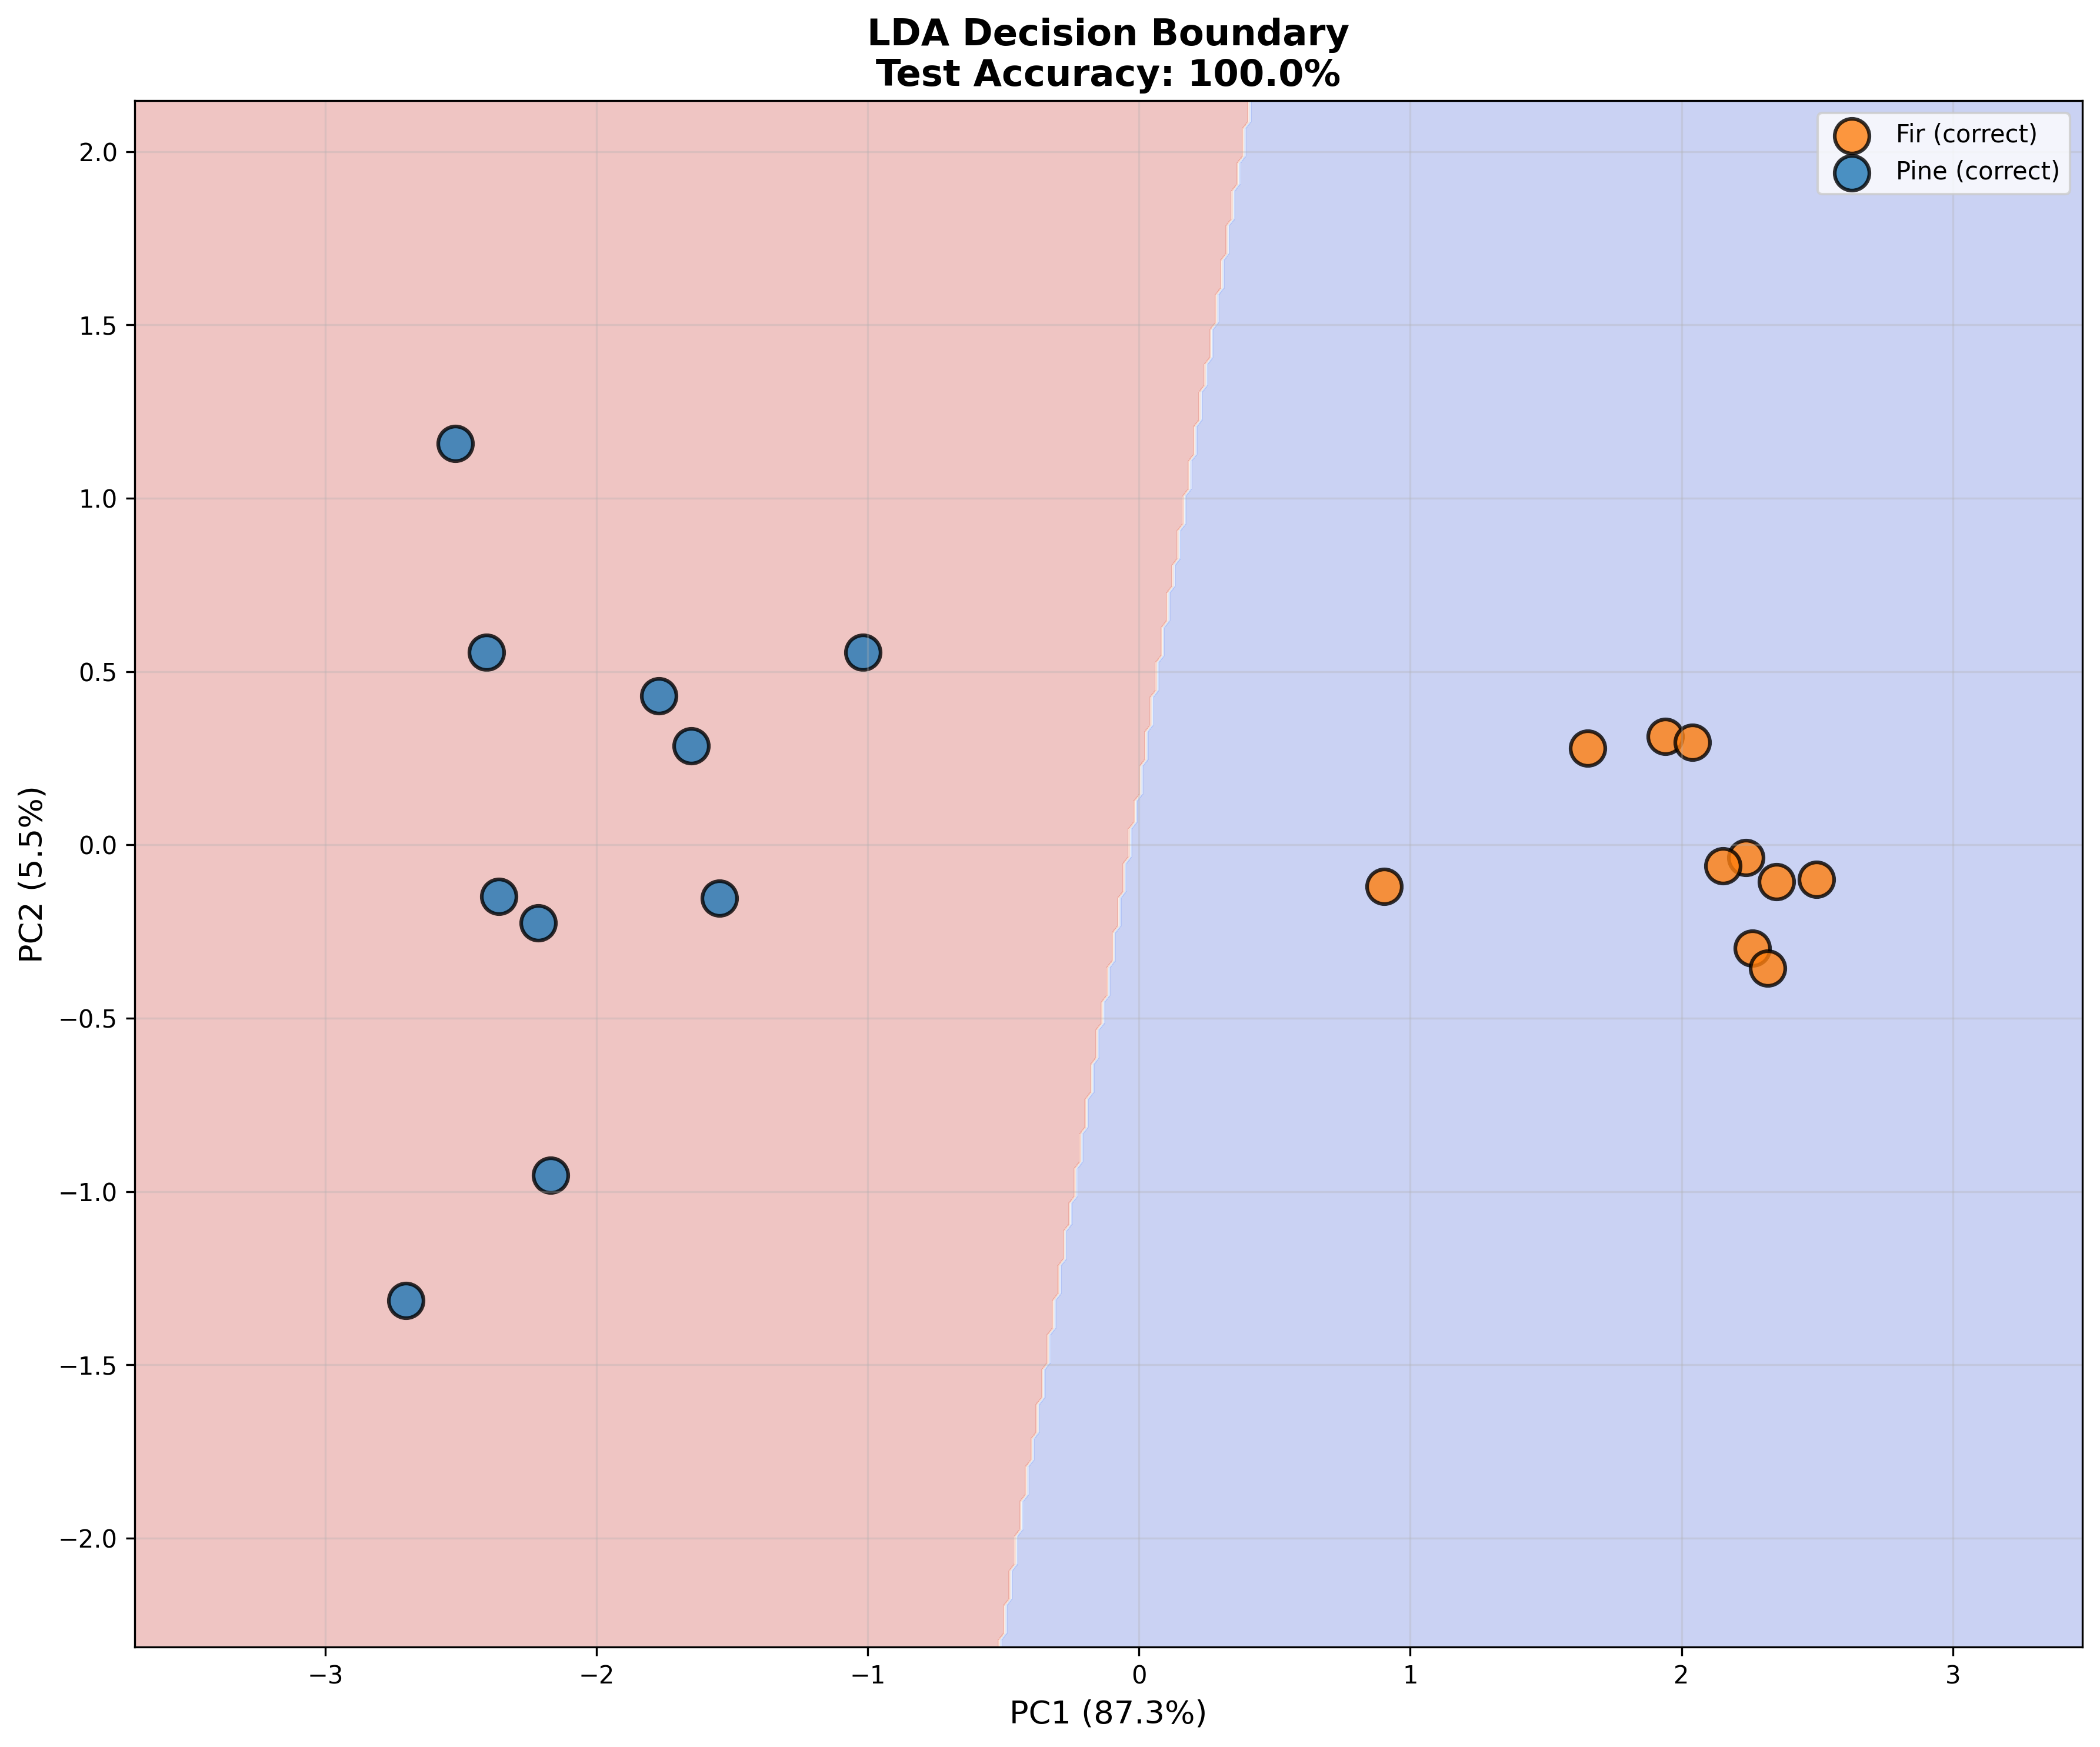

✓ Saved: lda_probability_distributions.png


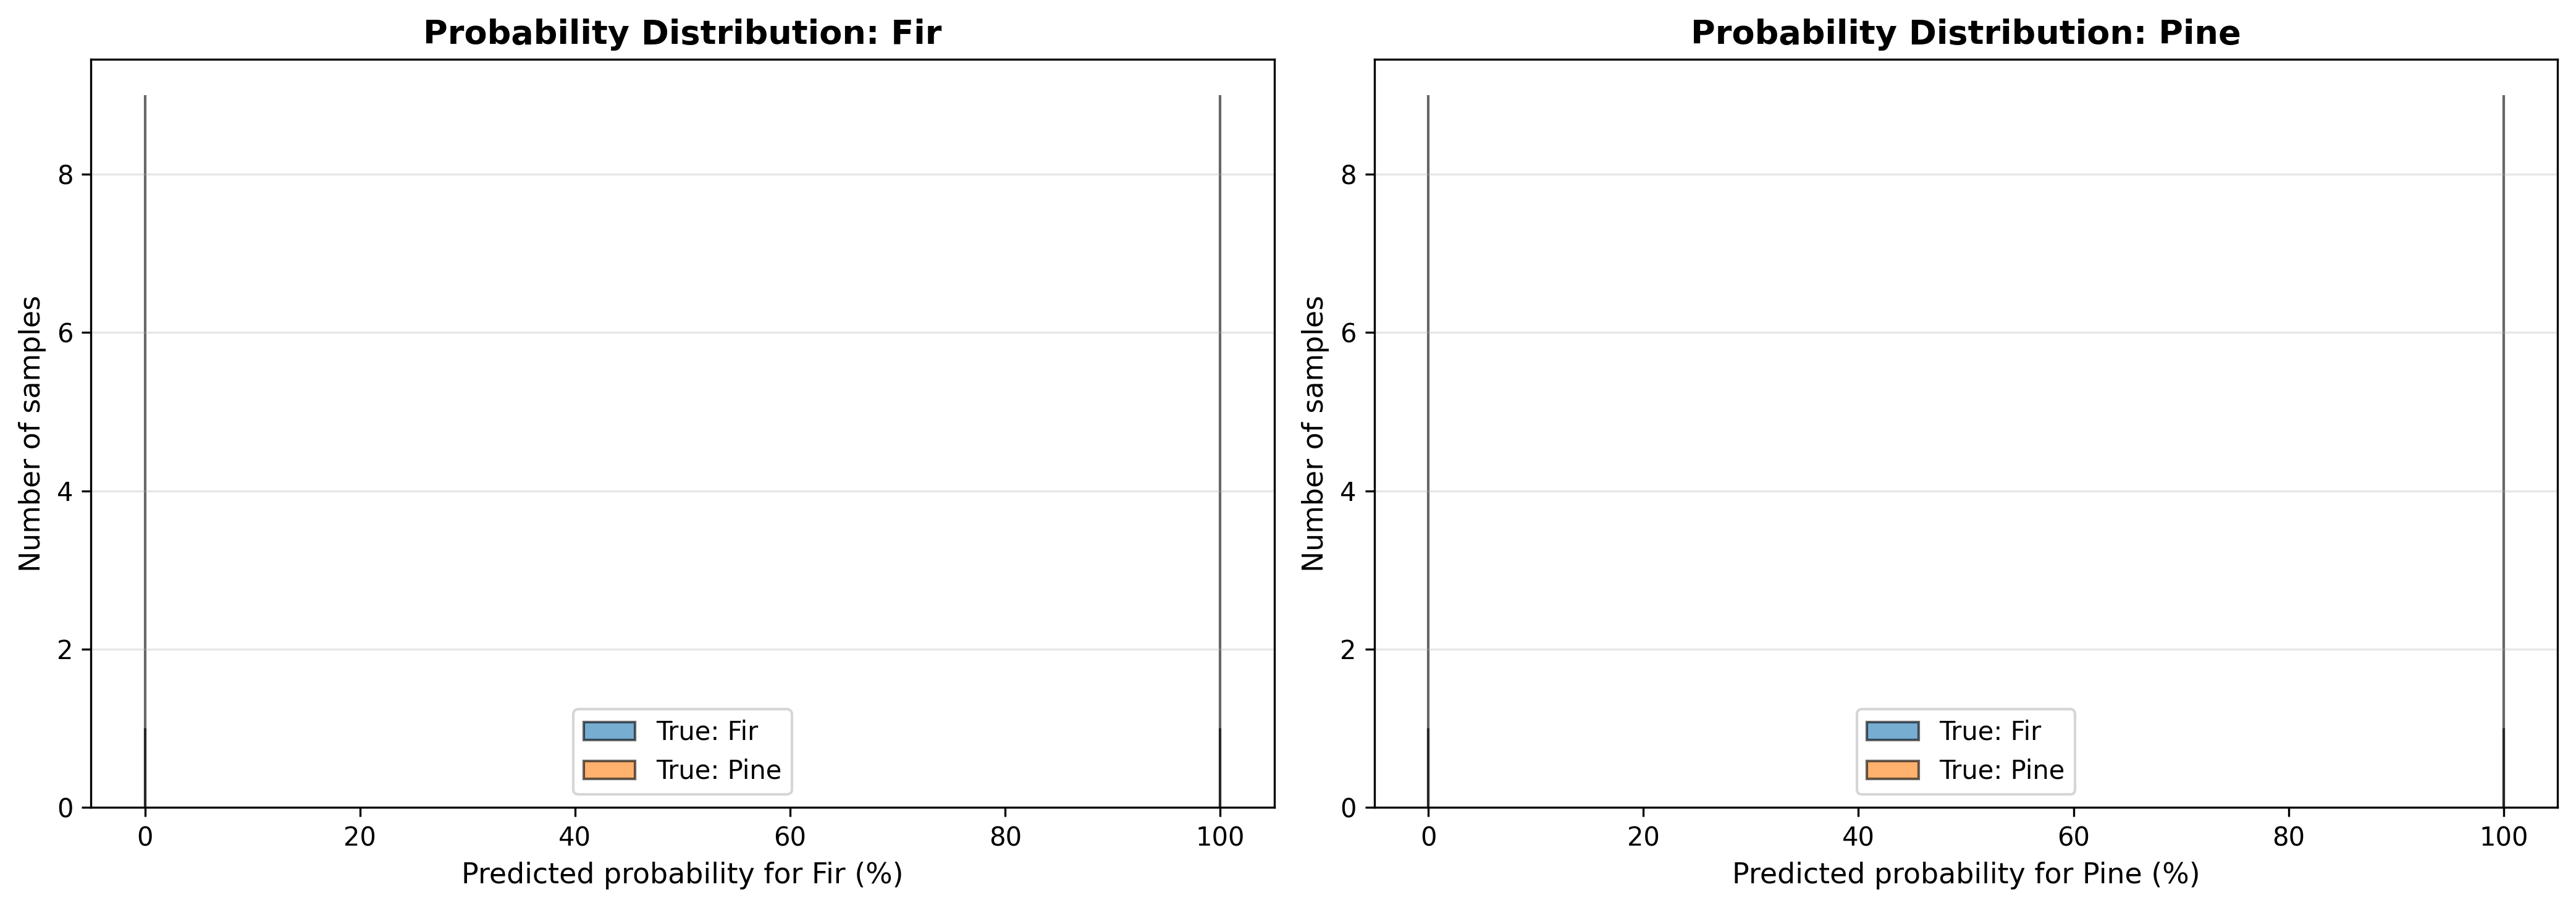


✓ Saved: lda_classification_results.csv

🎉 COMPLETE ANALYSIS FINISHED!

📊 FINAL RESULTS:
  Selected compounds: 5
  PC1+PC2 variance: 92.8%
  K-means clusters: 2
  LDA training accuracy: 100.0%
  LDA test accuracy: 100.0%

✅ All steps complete:
  ✓ Data cleaning
  ✓ Feature selection (ANOVA)
  ✓ PCA dimensionality reduction
  ✓ K-means clustering
  ✓ LDA classification

📁 Files generated:
  - f_ratio_analysis.png
  - pca_plot.png
  - kmeans_elbow_plot.png
  - kmeans_clustering.png
  - lda_decision_boundary.png
  - lda_probability_distributions.png
  - lda_classification_results.csv

🎯 You've successfully replicated the paper's methodology!


In [15]:
"""
LDA - LINEAR DISCRIMINANT ANALYSIS (CLASSIFICATION)
Final step! Train a model to predict fuel types
Uses X_pca and y from previous steps
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split

plt.rcParams['figure.dpi'] = 300

# =============================================================================
# LDA CLASSIFICATION
# =============================================================================
print("\n" + "="*80)
print("LINEAR DISCRIMINANT ANALYSIS (LDA)")
print("="*80)

# Use PC1 and PC2 as features (like the paper)
X_for_lda = X_pca[:, [0, 1]]  # PC1 and PC2

print(f"✓ Using PC1 and PC2 for LDA")
print(f"  Features: {X_for_lda.shape}")
print(f"  Labels: {y.shape}")
print(f"  Fuel families: {np.unique(y)}")

# =============================================================================
# TRAIN/TEST SPLIT (70/30 like the paper)
# =============================================================================
print("\n" + "="*80)
print("TRAIN/TEST SPLIT (70/30)")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X_for_lda,
    y,
    test_size=0.3,
    train_size=0.7,
    random_state=42,
    stratify=y  # Ensures balanced split
)

print(f"✓ Data split:")
print(f"  Training: {len(X_train)} samples")
print(f"  Testing:  {len(X_test)} samples")

print(f"\nTraining set distribution:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for fuel, count in zip(unique_train, counts_train):
    print(f"  {fuel}: {count} samples")

print(f"\nTest set distribution:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for fuel, count in zip(unique_test, counts_test):
    print(f"  {fuel}: {count} samples")

# =============================================================================
# TRAIN LDA MODEL
# =============================================================================
print("\n" + "="*80)
print("TRAINING LDA MODEL")
print("="*80)

lda = LDA()
lda.fit(X_train, y_train)

print(f"✓ LDA model trained")
print(f"  Number of classes: {len(lda.classes_)}")
print(f"  Classes: {lda.classes_}")

# =============================================================================
# EVALUATE MODEL
# =============================================================================
print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

# Accuracy on training set
train_accuracy = lda.score(X_train, y_train)
print(f"Training accuracy: {train_accuracy*100:.1f}%")

# Accuracy on test set
test_accuracy = lda.score(X_test, y_test)
print(f"Test accuracy: {test_accuracy*100:.1f}%")

# =============================================================================
# PREDICTIONS AND PROBABILITIES
# =============================================================================
print("\n" + "="*80)
print("PREDICTIONS ON ALL DATA")
print("="*80)

# Predict on all samples
y_pred = lda.predict(X_for_lda)
y_pred_proba = lda.predict_proba(X_for_lda)

# Create results dataframe
results_df = pd.DataFrame({
    'Sample': df_cleaned['Burn_No'].values,
    'True_Fuel': y,
    'Predicted_Fuel': y_pred
})

# Add probability columns for each fuel type
for i, fuel in enumerate(lda.classes_):
    results_df[f'{fuel}_Probability_%'] = y_pred_proba[:, i] * 100

print("\nSample predictions:")
print(results_df.head(10))

# =============================================================================
# CONFUSION MATRIX
# =============================================================================
print("\n" + "="*80)
print("CONFUSION MATRIX (Test Set)")
print("="*80)

y_test_pred = lda.predict(X_test)

confusion = pd.crosstab(
    y_test,
    y_test_pred,
    rownames=['Actual'],
    colnames=['Predicted'],
    margins=True  # Add totals
)
print(confusion)

# Calculate per-class accuracy
print("\nPer-class accuracy:")
for fuel in np.unique(y_test):
    mask = y_test == fuel
    correct = (y_test[mask] == y_test_pred[mask]).sum()
    total = mask.sum()
    accuracy = (correct / total * 100) if total > 0 else 0
    print(f"  {fuel}: {correct}/{total} = {accuracy:.1f}%")

# =============================================================================
# VISUALIZE DECISION BOUNDARY
# =============================================================================
print("\n" + "="*80)
print("VISUALIZING DECISION BOUNDARY")
print("="*80)

fig, ax = plt.subplots(figsize=(12, 10))

# Create mesh for decision boundary
h = 0.02  # Step size
x_min, x_max = X_for_lda[:, 0].min() - 1, X_for_lda[:, 0].max() + 1
y_min, y_max = X_for_lda[:, 1].min() - 1, X_for_lda[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict on mesh
Z = lda.predict(np.c_[xx.ravel(), yy.ravel()])

# Convert fuel names to numbers for plotting
fuel_to_num = {fuel: i for i, fuel in enumerate(lda.classes_)}
Z_num = np.array([fuel_to_num[fuel] for fuel in Z])
Z_num = Z_num.reshape(xx.shape)

# Plot decision boundary
ax.contourf(xx, yy, Z_num, alpha=0.3, cmap='coolwarm')

# Plot data points
colors_fuel = {'Pine': '#1f77b4', 'Fir': '#ff7f0e', 'Spruce': '#2ca02c'}
markers = {'correct': 'o', 'incorrect': 'X'}

for fuel in np.unique(y):
    mask = y == fuel
    correct_mask = mask & (y_pred == y)
    incorrect_mask = mask & (y_pred != y)

    # Plot correct predictions
    if correct_mask.sum() > 0:
        ax.scatter(
            X_for_lda[correct_mask, 0],
            X_for_lda[correct_mask, 1],
            c=[colors_fuel.get(fuel, 'gray')],
            marker='o',
            s=200,
            edgecolors='black',
            linewidths=1.5,
            label=f'{fuel} (correct)',
            alpha=0.8
        )

    # Plot incorrect predictions
    if incorrect_mask.sum() > 0:
        ax.scatter(
            X_for_lda[incorrect_mask, 0],
            X_for_lda[incorrect_mask, 1],
            c=[colors_fuel.get(fuel, 'gray')],
            marker='X',
            s=200,
            edgecolors='red',
            linewidths=2,
            label=f'{fuel} (incorrect)',
            alpha=0.8
        )

var1 = pca_full.explained_variance_ratio_[0] * 100
var2 = pca_full.explained_variance_ratio_[1] * 100

ax.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=13)
ax.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=13)
ax.set_title(f'LDA Decision Boundary\nTest Accuracy: {test_accuracy*100:.1f}%',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lda_decision_boundary.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: lda_decision_boundary.png")
plt.show()

# =============================================================================
# VISUALIZE PROBABILITY DISTRIBUTIONS
# =============================================================================

if len(lda.classes_) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for i, fuel in enumerate(lda.classes_):
        ax = axes[i]

        # Get probabilities for this fuel
        probs = y_pred_proba[:, i] * 100

        # Separate by true label
        for true_fuel in lda.classes_:
            mask = y == true_fuel
            ax.hist(probs[mask], bins=20, alpha=0.6,
                   label=f'True: {true_fuel}',
                   edgecolor='black')

        ax.set_xlabel(f'Predicted probability for {fuel} (%)', fontsize=11)
        ax.set_ylabel('Number of samples', fontsize=11)
        ax.set_title(f'Probability Distribution: {fuel}', fontsize=13, fontweight='bold')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('lda_probability_distributions.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: lda_probability_distributions.png")
    plt.show()

# =============================================================================
# SAVE RESULTS
# =============================================================================

results_df.to_csv('lda_classification_results.csv', index=False)
print("\n✓ Saved: lda_classification_results.csv")

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "="*80)
print("🎉 COMPLETE ANALYSIS FINISHED!")
print("="*80)

print("\n📊 FINAL RESULTS:")
print(f"  Selected compounds: {n_features}")
print(f"  PC1+PC2 variance: {(pca_full.explained_variance_ratio_[0] + pca_full.explained_variance_ratio_[1])*100:.1f}%")
print(f"  K-means clusters: {optimal_k}")
print(f"  LDA training accuracy: {train_accuracy*100:.1f}%")
print(f"  LDA test accuracy: {test_accuracy*100:.1f}%")

print("\n✅ All steps complete:")
print("  ✓ Data cleaning")
print("  ✓ Feature selection (ANOVA)")
print("  ✓ PCA dimensionality reduction")
print("  ✓ K-means clustering")
print("  ✓ LDA classification")

print("\n📁 Files generated:")
print("  - f_ratio_analysis.png")
print("  - pca_plot.png")
print("  - kmeans_elbow_plot.png")
print("  - kmeans_clustering.png")
print("  - lda_decision_boundary.png")
print("  - lda_probability_distributions.png")
print("  - lda_classification_results.csv")

print("\n🎯 You've successfully replicated the paper's methodology!")


RANDOM FOREST vs LDA COMPARISON
✓ Using PC1 and PC2
  Features: (20, 2)
  Labels: (20,)
  Fuel families: ['Fir' 'Pine']

TRAIN/TEST SPLIT (70/30)
✓ Training: 14 samples
✓ Testing:  6 samples

TRAINING MODELS
✓ LDA trained
✓ Random Forest trained

ACCURACY COMPARISON
Model                Training Acc    Test Acc       
--------------------------------------------------
LDA                   100.0%         100.0%
Random Forest         100.0%         100.0%
--------------------------------------------------
Difference (RF - LDA)   +0.0%          +0.0%

TEST SET PREDICTIONS

LDA Confusion Matrix:
Predicted  Fir  Pine
Actual              
Fir          3     0
Pine         0     3

Random Forest Confusion Matrix:
Predicted  Fir  Pine
Actual              
Fir          3     0
Pine         0     3

RANDOM FOREST FEATURE IMPORTANCE
PC1 importance: 0.710
PC2 importance: 0.290

VISUALIZING DECISION BOUNDARIES

✓ Saved: lda_vs_random_forest.png


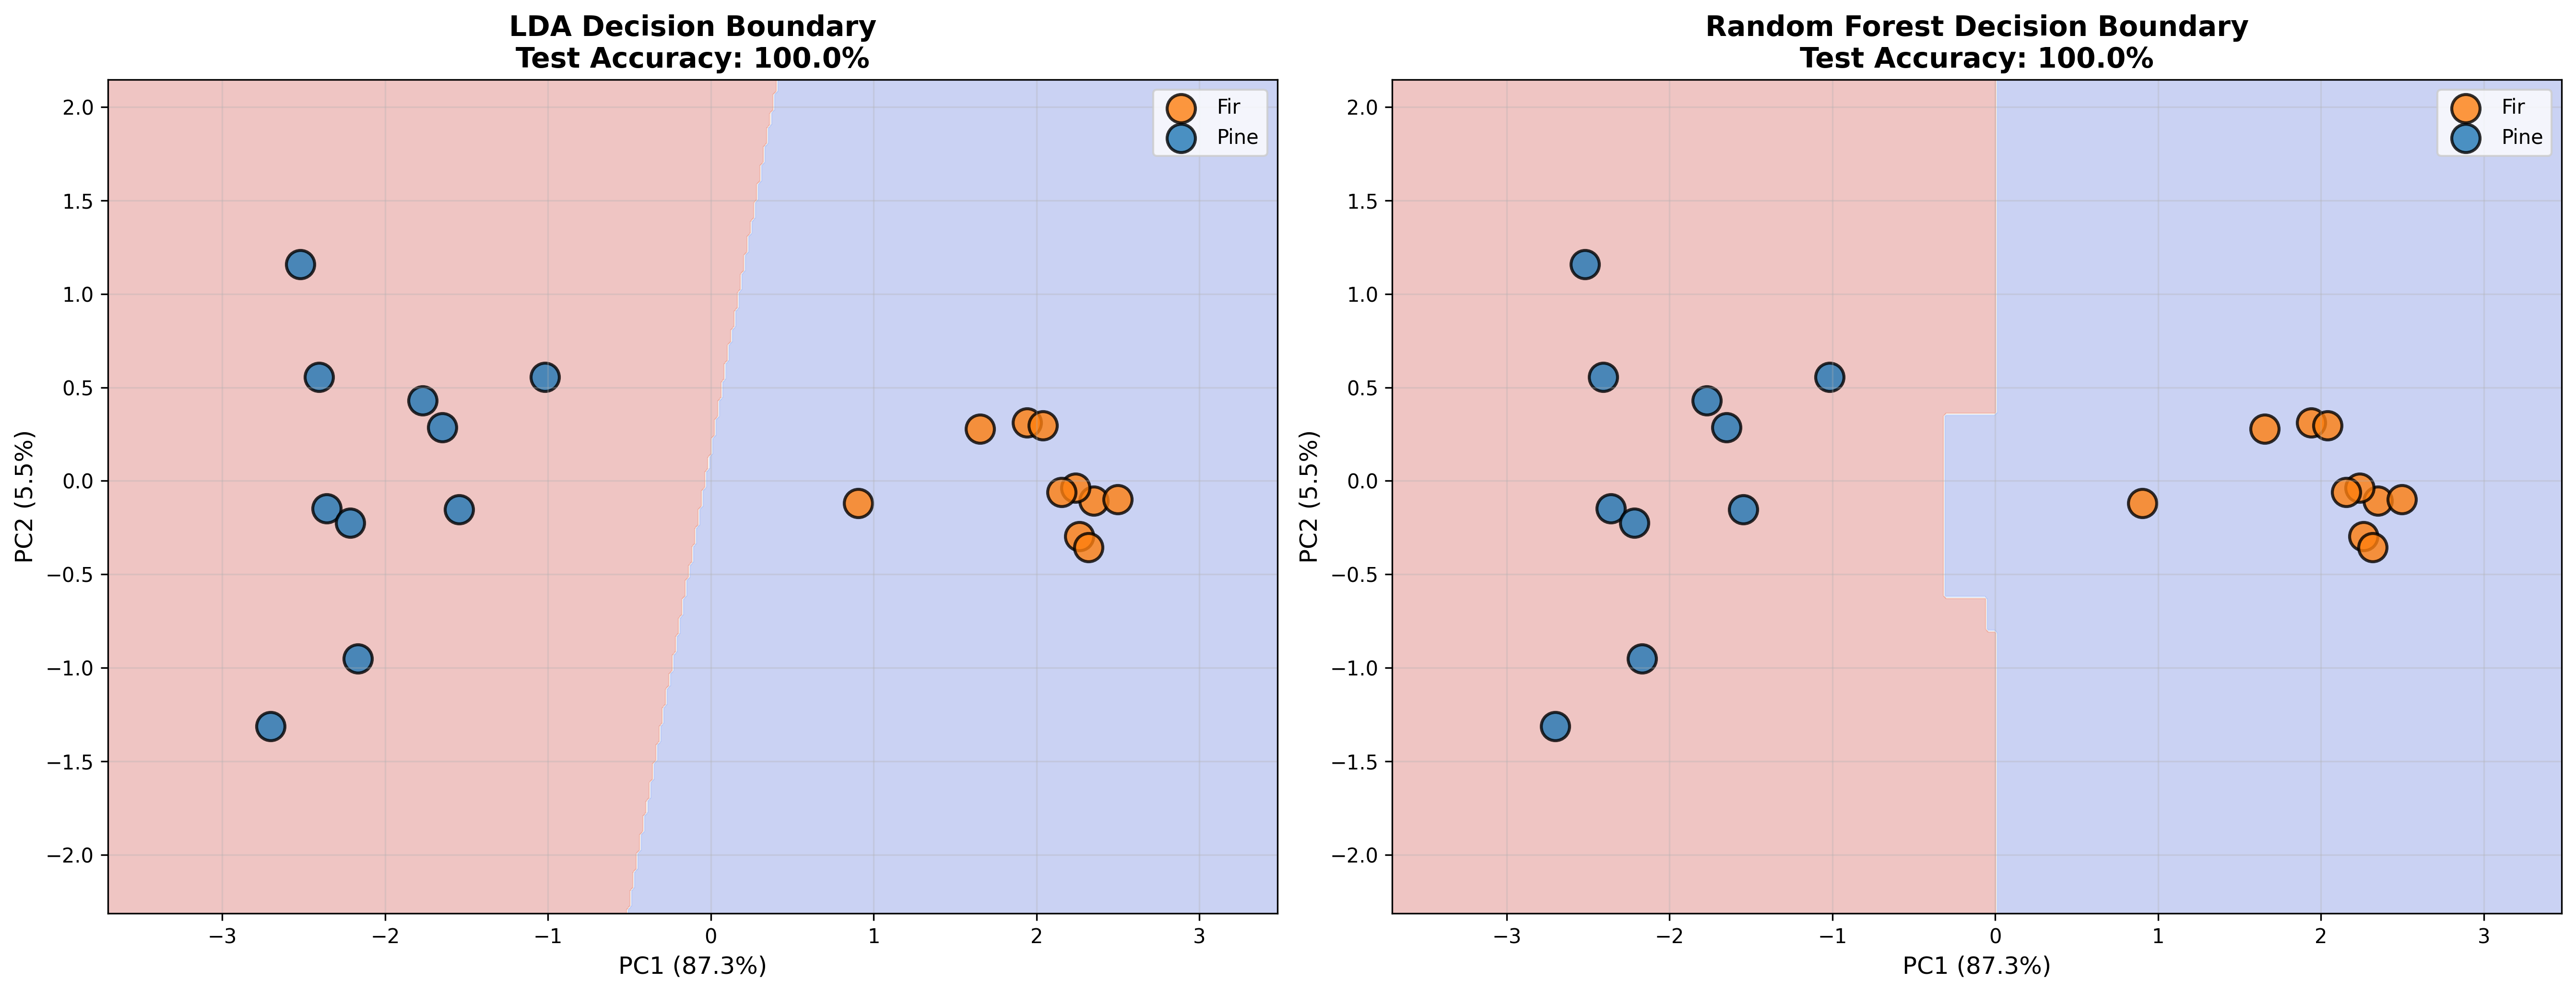

✓ Saved: probability_comparison.png


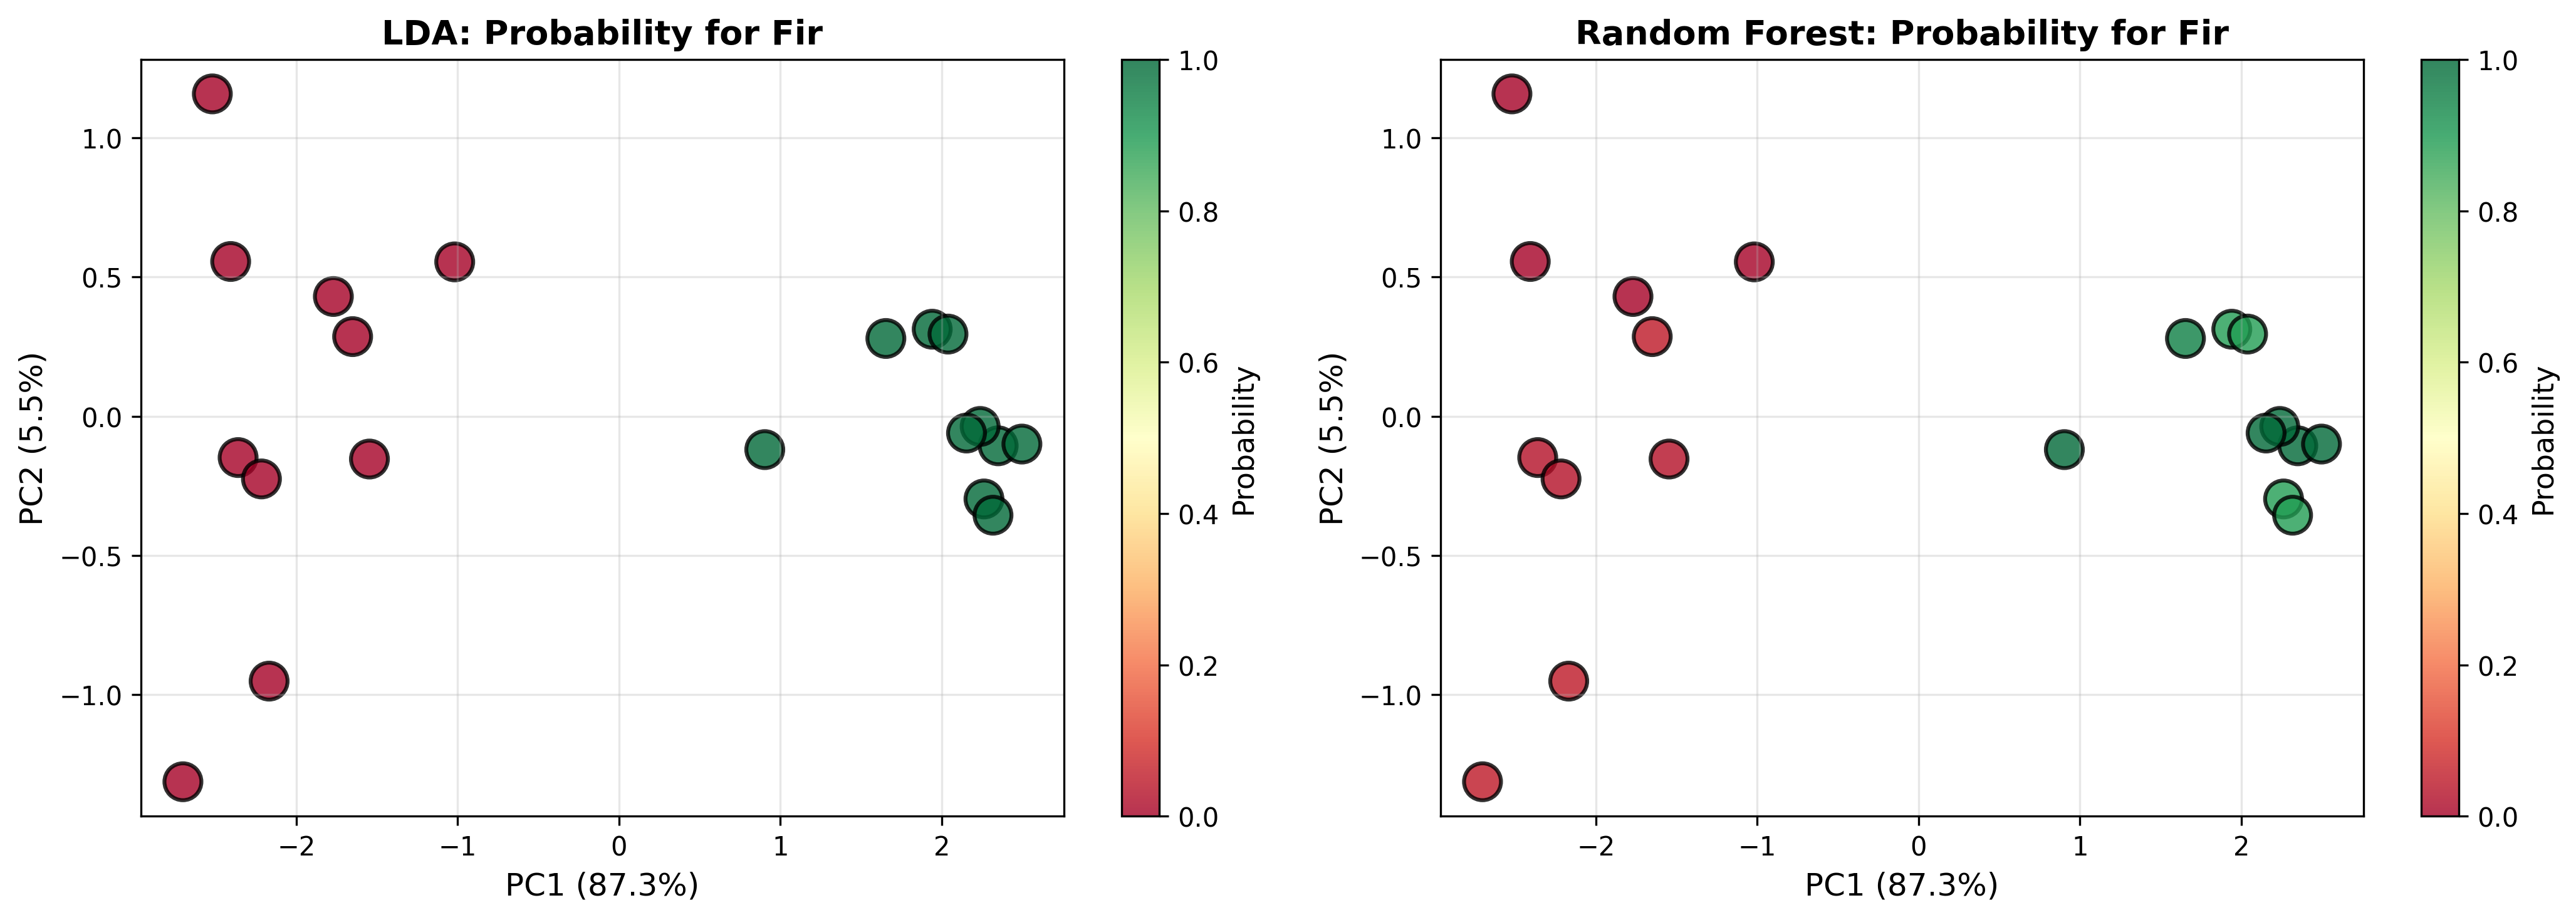


FINAL VERDICT

📊 ACCURACY:
  LDA:           Train=100.0%, Test=100.0%
  Random Forest: Train=100.0%, Test=100.0%

🏆 WINNER: TIE

📉 OVERFITTING CHECK:
  LDA gap (train - test):           0.0%
  Random Forest gap (train - test): 0.0%
  → Both generalize equally well

💡 RECOMMENDATION:
  ✅ Use LDA - simpler, interpretable, performs as well or better

📁 Files saved:
  - lda_vs_random_forest.png
  - probability_comparison.png


In [16]:
"""
RANDOM FOREST CLASSIFICATION (COMPARISON)
Compare Random Forest vs LDA on the same data
Uses X_pca and y from previous steps
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

plt.rcParams['figure.dpi'] = 300

# =============================================================================
# PREPARE DATA (SAME AS LDA)
# =============================================================================
print("\n" + "="*80)
print("RANDOM FOREST vs LDA COMPARISON")
print("="*80)

# Use PC1 and PC2 (same as LDA for fair comparison)
X_for_classification = X_pca[:, [0, 1]]

print(f"✓ Using PC1 and PC2")
print(f"  Features: {X_for_classification.shape}")
print(f"  Labels: {y.shape}")
print(f"  Fuel families: {np.unique(y)}")

# =============================================================================
# TRAIN/TEST SPLIT (SAME AS LDA - 70/30)
# =============================================================================
print("\n" + "="*80)
print("TRAIN/TEST SPLIT (70/30)")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X_for_classification,
    y,
    test_size=0.3,
    train_size=0.7,
    random_state=42,  # Same seed for fair comparison
    stratify=y
)

print(f"✓ Training: {len(X_train)} samples")
print(f"✓ Testing:  {len(X_test)} samples")

# =============================================================================
# TRAIN BOTH MODELS
# =============================================================================
print("\n" + "="*80)
print("TRAINING MODELS")
print("="*80)

# LDA
lda = LDA()
lda.fit(X_train, y_train)
print("✓ LDA trained")

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=None,        # No limit on depth
    min_samples_split=2,   # Minimum samples to split
    min_samples_leaf=1,    # Minimum samples per leaf
    random_state=42,       # Reproducibility
    n_jobs=-1              # Use all CPU cores
)
rf.fit(X_train, y_train)
print("✓ Random Forest trained")

# =============================================================================
# COMPARE ACCURACIES
# =============================================================================
print("\n" + "="*80)
print("ACCURACY COMPARISON")
print("="*80)

# LDA scores
lda_train_acc = lda.score(X_train, y_train)
lda_test_acc = lda.score(X_test, y_test)

# Random Forest scores
rf_train_acc = rf.score(X_train, y_train)
rf_test_acc = rf.score(X_test, y_test)

# Display comparison
print(f"{'Model':<20} {'Training Acc':<15} {'Test Acc':<15}")
print("-" * 50)
print(f"{'LDA':<20} {lda_train_acc*100:>6.1f}%        {lda_test_acc*100:>6.1f}%")
print(f"{'Random Forest':<20} {rf_train_acc*100:>6.1f}%        {rf_test_acc*100:>6.1f}%")

# Calculate difference
diff_train = (rf_train_acc - lda_train_acc) * 100
diff_test = (rf_test_acc - lda_test_acc) * 100
print("-" * 50)
print(f"{'Difference (RF - LDA)':<20} {diff_train:>+6.1f}%        {diff_test:>+6.1f}%")

# =============================================================================
# PREDICTIONS ON TEST SET
# =============================================================================
print("\n" + "="*80)
print("TEST SET PREDICTIONS")
print("="*80)

y_pred_lda = lda.predict(X_test)
y_pred_rf = rf.predict(X_test)

# LDA Confusion Matrix
print("\nLDA Confusion Matrix:")
print(pd.crosstab(y_test, y_pred_lda,
                  rownames=['Actual'],
                  colnames=['Predicted']))

# Random Forest Confusion Matrix
print("\nRandom Forest Confusion Matrix:")
print(pd.crosstab(y_test, y_pred_rf,
                  rownames=['Actual'],
                  colnames=['Predicted']))

# =============================================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# =============================================================================
print("\n" + "="*80)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("="*80)

print(f"PC1 importance: {rf.feature_importances_[0]:.3f}")
print(f"PC2 importance: {rf.feature_importances_[1]:.3f}")

# =============================================================================
# VISUALIZE DECISION BOUNDARIES (SIDE BY SIDE)
# =============================================================================
print("\n" + "="*80)
print("VISUALIZING DECISION BOUNDARIES")
print("="*80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Create mesh
h = 0.02
x_min, x_max = X_for_classification[:, 0].min() - 1, X_for_classification[:, 0].max() + 1
y_min, y_max = X_for_classification[:, 1].min() - 1, X_for_classification[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict on mesh for both models
Z_lda = lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rf = rf.predict(np.c_[xx.ravel(), yy.ravel()])

# Convert to numeric for plotting
fuel_to_num = {fuel: i for i, fuel in enumerate(np.unique(y))}
Z_lda_num = np.array([fuel_to_num[fuel] for fuel in Z_lda]).reshape(xx.shape)
Z_rf_num = np.array([fuel_to_num[fuel] for fuel in Z_rf]).reshape(xx.shape)

colors_fuel = {'Pine': '#1f77b4', 'Fir': '#ff7f0e', 'Spruce': '#2ca02c'}

# Plot 1: LDA
ax1.contourf(xx, yy, Z_lda_num, alpha=0.3, cmap='coolwarm')

for fuel in np.unique(y):
    mask = y == fuel
    ax1.scatter(
        X_for_classification[mask, 0],
        X_for_classification[mask, 1],
        c=[colors_fuel.get(fuel, 'gray')],
        s=200,
        edgecolors='black',
        linewidths=1.5,
        label=fuel,
        alpha=0.8
    )

var1 = pca_full.explained_variance_ratio_[0] * 100
var2 = pca_full.explained_variance_ratio_[1] * 100

ax1.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=12)
ax1.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=12)
ax1.set_title(f'LDA Decision Boundary\nTest Accuracy: {lda_test_acc*100:.1f}%',
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Random Forest
ax2.contourf(xx, yy, Z_rf_num, alpha=0.3, cmap='coolwarm')

for fuel in np.unique(y):
    mask = y == fuel
    ax2.scatter(
        X_for_classification[mask, 0],
        X_for_classification[mask, 1],
        c=[colors_fuel.get(fuel, 'gray')],
        s=200,
        edgecolors='black',
        linewidths=1.5,
        label=fuel,
        alpha=0.8
    )

ax2.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=12)
ax2.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=12)
ax2.set_title(f'Random Forest Decision Boundary\nTest Accuracy: {rf_test_acc*100:.1f}%',
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lda_vs_random_forest.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: lda_vs_random_forest.png")
plt.show()

# =============================================================================
# PROBABILITY PREDICTIONS COMPARISON
# =============================================================================

# Get probabilities for all data
lda_proba = lda.predict_proba(X_for_classification)
rf_proba = rf.predict_proba(X_for_classification)

# Compare probabilities for first fuel type
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fuel_classes = lda.classes_

# LDA probabilities
for i, fuel in enumerate(fuel_classes):
    mask = y == fuel
    ax1.scatter(X_for_classification[mask, 0],
               X_for_classification[mask, 1],
               c=lda_proba[mask, 0],  # Probability for first class
               s=200,
               cmap='RdYlGn',
               vmin=0, vmax=1,
               edgecolors='black',
               linewidths=1.5,
               alpha=0.8)

ax1.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=12)
ax1.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=12)
ax1.set_title(f'LDA: Probability for {fuel_classes[0]}', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(ax1.collections[0], ax=ax1)
cbar1.set_label('Probability', fontsize=11)

# Random Forest probabilities
for i, fuel in enumerate(fuel_classes):
    mask = y == fuel
    ax2.scatter(X_for_classification[mask, 0],
               X_for_classification[mask, 1],
               c=rf_proba[mask, 0],
               s=200,
               cmap='RdYlGn',
               vmin=0, vmax=1,
               edgecolors='black',
               linewidths=1.5,
               alpha=0.8)

ax2.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=12)
ax2.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=12)
ax2.set_title(f'Random Forest: Probability for {fuel_classes[0]}', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
cbar2 = plt.colorbar(ax2.collections[0], ax=ax2)
cbar2.set_label('Probability', fontsize=11)

plt.tight_layout()
plt.savefig('probability_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: probability_comparison.png")
plt.show()

# =============================================================================
# FINAL COMPARISON SUMMARY
# =============================================================================
print("\n" + "="*80)
print("FINAL VERDICT")
print("="*80)

print(f"\n📊 ACCURACY:")
print(f"  LDA:           Train={lda_train_acc*100:.1f}%, Test={lda_test_acc*100:.1f}%")
print(f"  Random Forest: Train={rf_train_acc*100:.1f}%, Test={rf_test_acc*100:.1f}%")

# Determine winner
if lda_test_acc > rf_test_acc:
    winner = "LDA"
    margin = (lda_test_acc - rf_test_acc) * 100
elif rf_test_acc > lda_test_acc:
    winner = "Random Forest"
    margin = (rf_test_acc - lda_test_acc) * 100
else:
    winner = "TIE"
    margin = 0

print(f"\n🏆 WINNER: {winner}", end="")
if margin > 0:
    print(f" (by {margin:.1f}%)")
else:
    print()

# Check for overfitting
print(f"\n📉 OVERFITTING CHECK:")
lda_gap = (lda_train_acc - lda_test_acc) * 100
rf_gap = (rf_train_acc - rf_test_acc) * 100

print(f"  LDA gap (train - test):           {lda_gap:.1f}%")
print(f"  Random Forest gap (train - test): {rf_gap:.1f}%")

if abs(lda_gap) < abs(rf_gap):
    print(f"  → LDA generalizes better (smaller gap)")
elif abs(rf_gap) < abs(lda_gap):
    print(f"  → Random Forest generalizes better (smaller gap)")
else:
    print(f"  → Both generalize equally well")

print(f"\n💡 RECOMMENDATION:")
if lda_test_acc >= rf_test_acc and abs(lda_gap) <= abs(rf_gap):
    print("  ✅ Use LDA - simpler, interpretable, performs as well or better")
elif rf_test_acc > lda_test_acc:
    print(f"  ⚠️ Random Forest wins by {margin:.1f}%, but check if difference is meaningful")
    print(f"     With only {len(X_test)} test samples, this could be noise")
else:
    print("  ✅ Both perform similarly - stick with LDA for interpretability")

print(f"\n📁 Files saved:")
print("  - lda_vs_random_forest.png")
print("  - probability_comparison.png")

TabNet--------------------------------------------------------------------------

In [18]:
# Install TabNet and dependencies
!pip install pytorch-tabnet
!pip install torch  # Will install appropriate version for your system
!pip install scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.2 MB/s eta 0:00:00


✓ TabNet imported successfully

PREPARING DATA FOR ALL THREE MODELS
✓ Using PC1 and PC2
  Features: (20, 2)
  Labels: (20,)
  Fuel families: ['Fir' 'Pine']

TRAIN/TEST SPLIT (70/30)
✓ Training: 14 samples
✓ Testing:  6 samples

✓ Label encoding:
  Fir → 0
  Pine → 1

TRAINING ALL MODELS

1. Training LDA...
   ✓ LDA trained

2. Training Random Forest...
   ✓ Random Forest trained

3. Training TabNet...
   ⚠️ WARNING: Only 14 training samples - TabNet will likely overfit!

Early stopping occurred at epoch 20 with best_epoch = 0 and best_val_0_accuracy = 1.0
   ✓ TabNet trained

ACCURACY COMPARISON

Model                Training Acc    Test Acc        Overfitting Gap
----------------------------------------------------------------------
LDA                   100.0%         100.0%          +0.0%
Random Forest         100.0%         100.0%          +0.0%
TabNet                100.0%         100.0%          +0.0%

🏆 BEST TEST ACCURACY: LDA (100.0%)

CONFUSION MATRICES (TEST SET)


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



LDA:
Predicted  Fir  Pine
Actual              
Fir          3     0
Pine         0     3

Random Forest:
Predicted  Fir  Pine
Actual              
Fir          3     0
Pine         0     3

TabNet:
Predicted  Fir  Pine
Actual              
Fir          3     0
Pine         0     3

VISUALIZING DECISION BOUNDARIES

✓ Saved: all_models_comparison.png


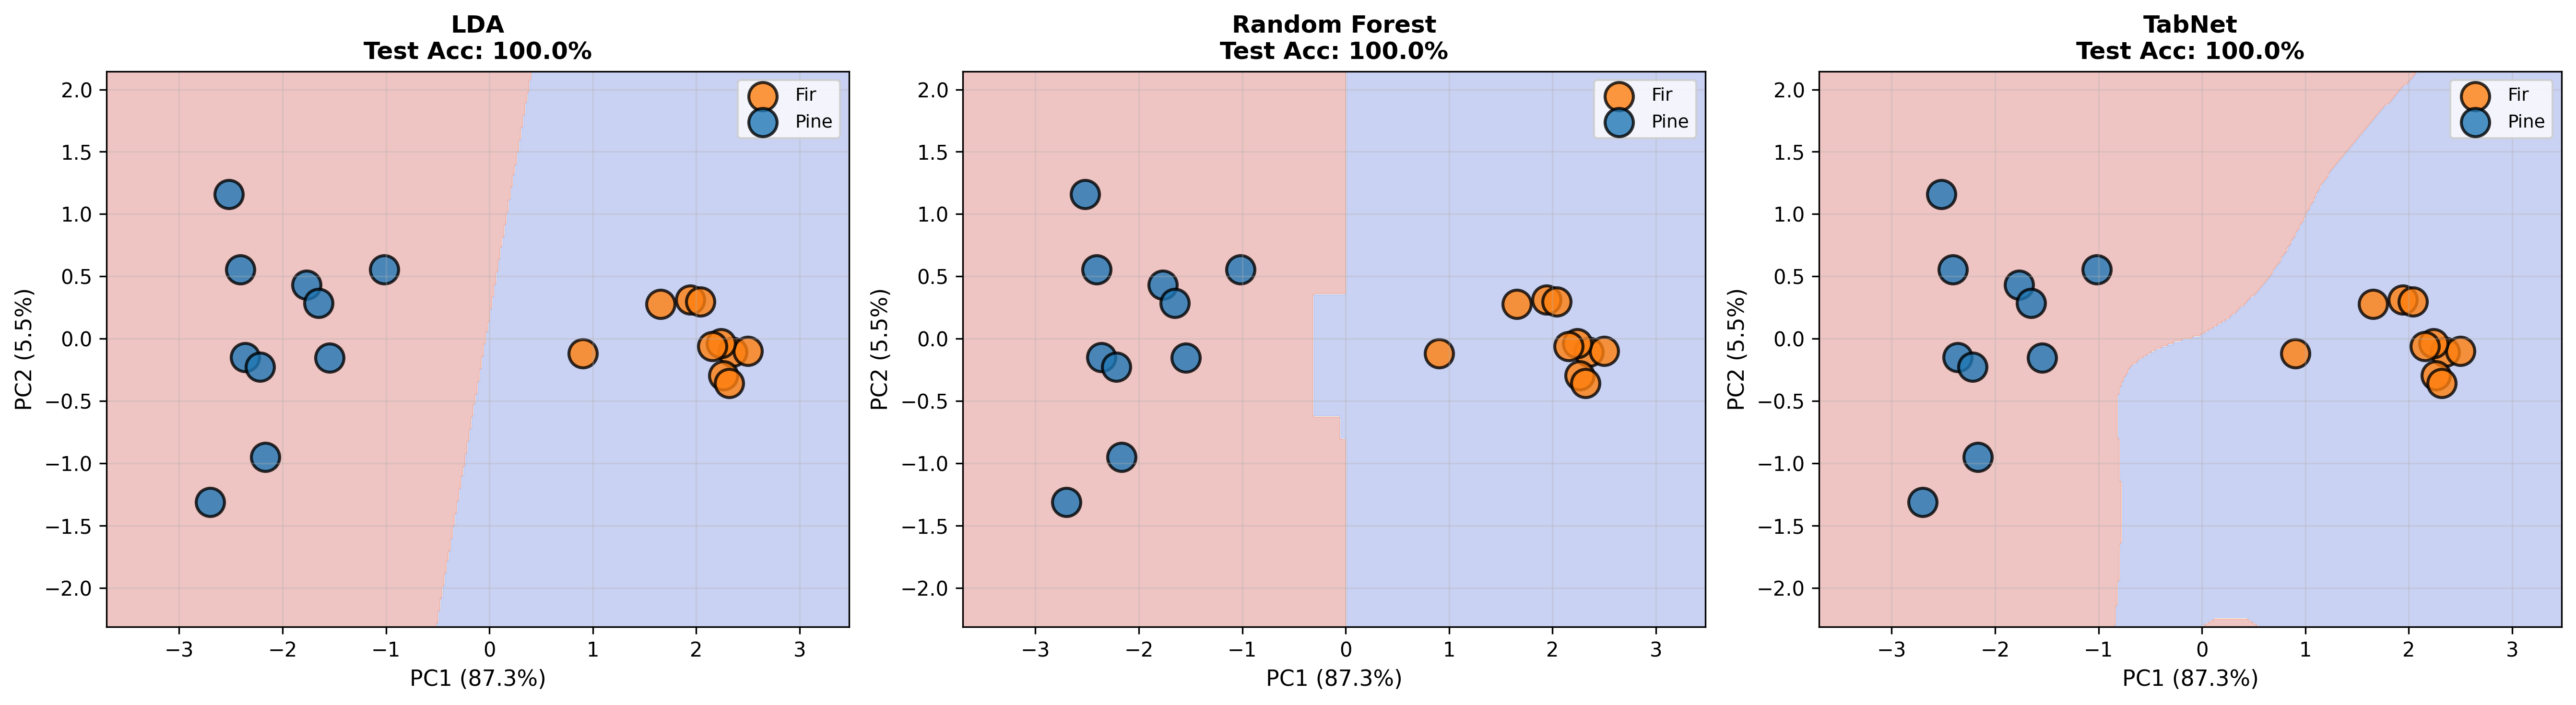


TABNET FEATURE IMPORTANCE (ATTENTION MECHANISM)

Feature importance:
Feature  Importance
    PC1    0.945902
    PC2    0.054098

✓ Saved: tabnet_feature_importance.png


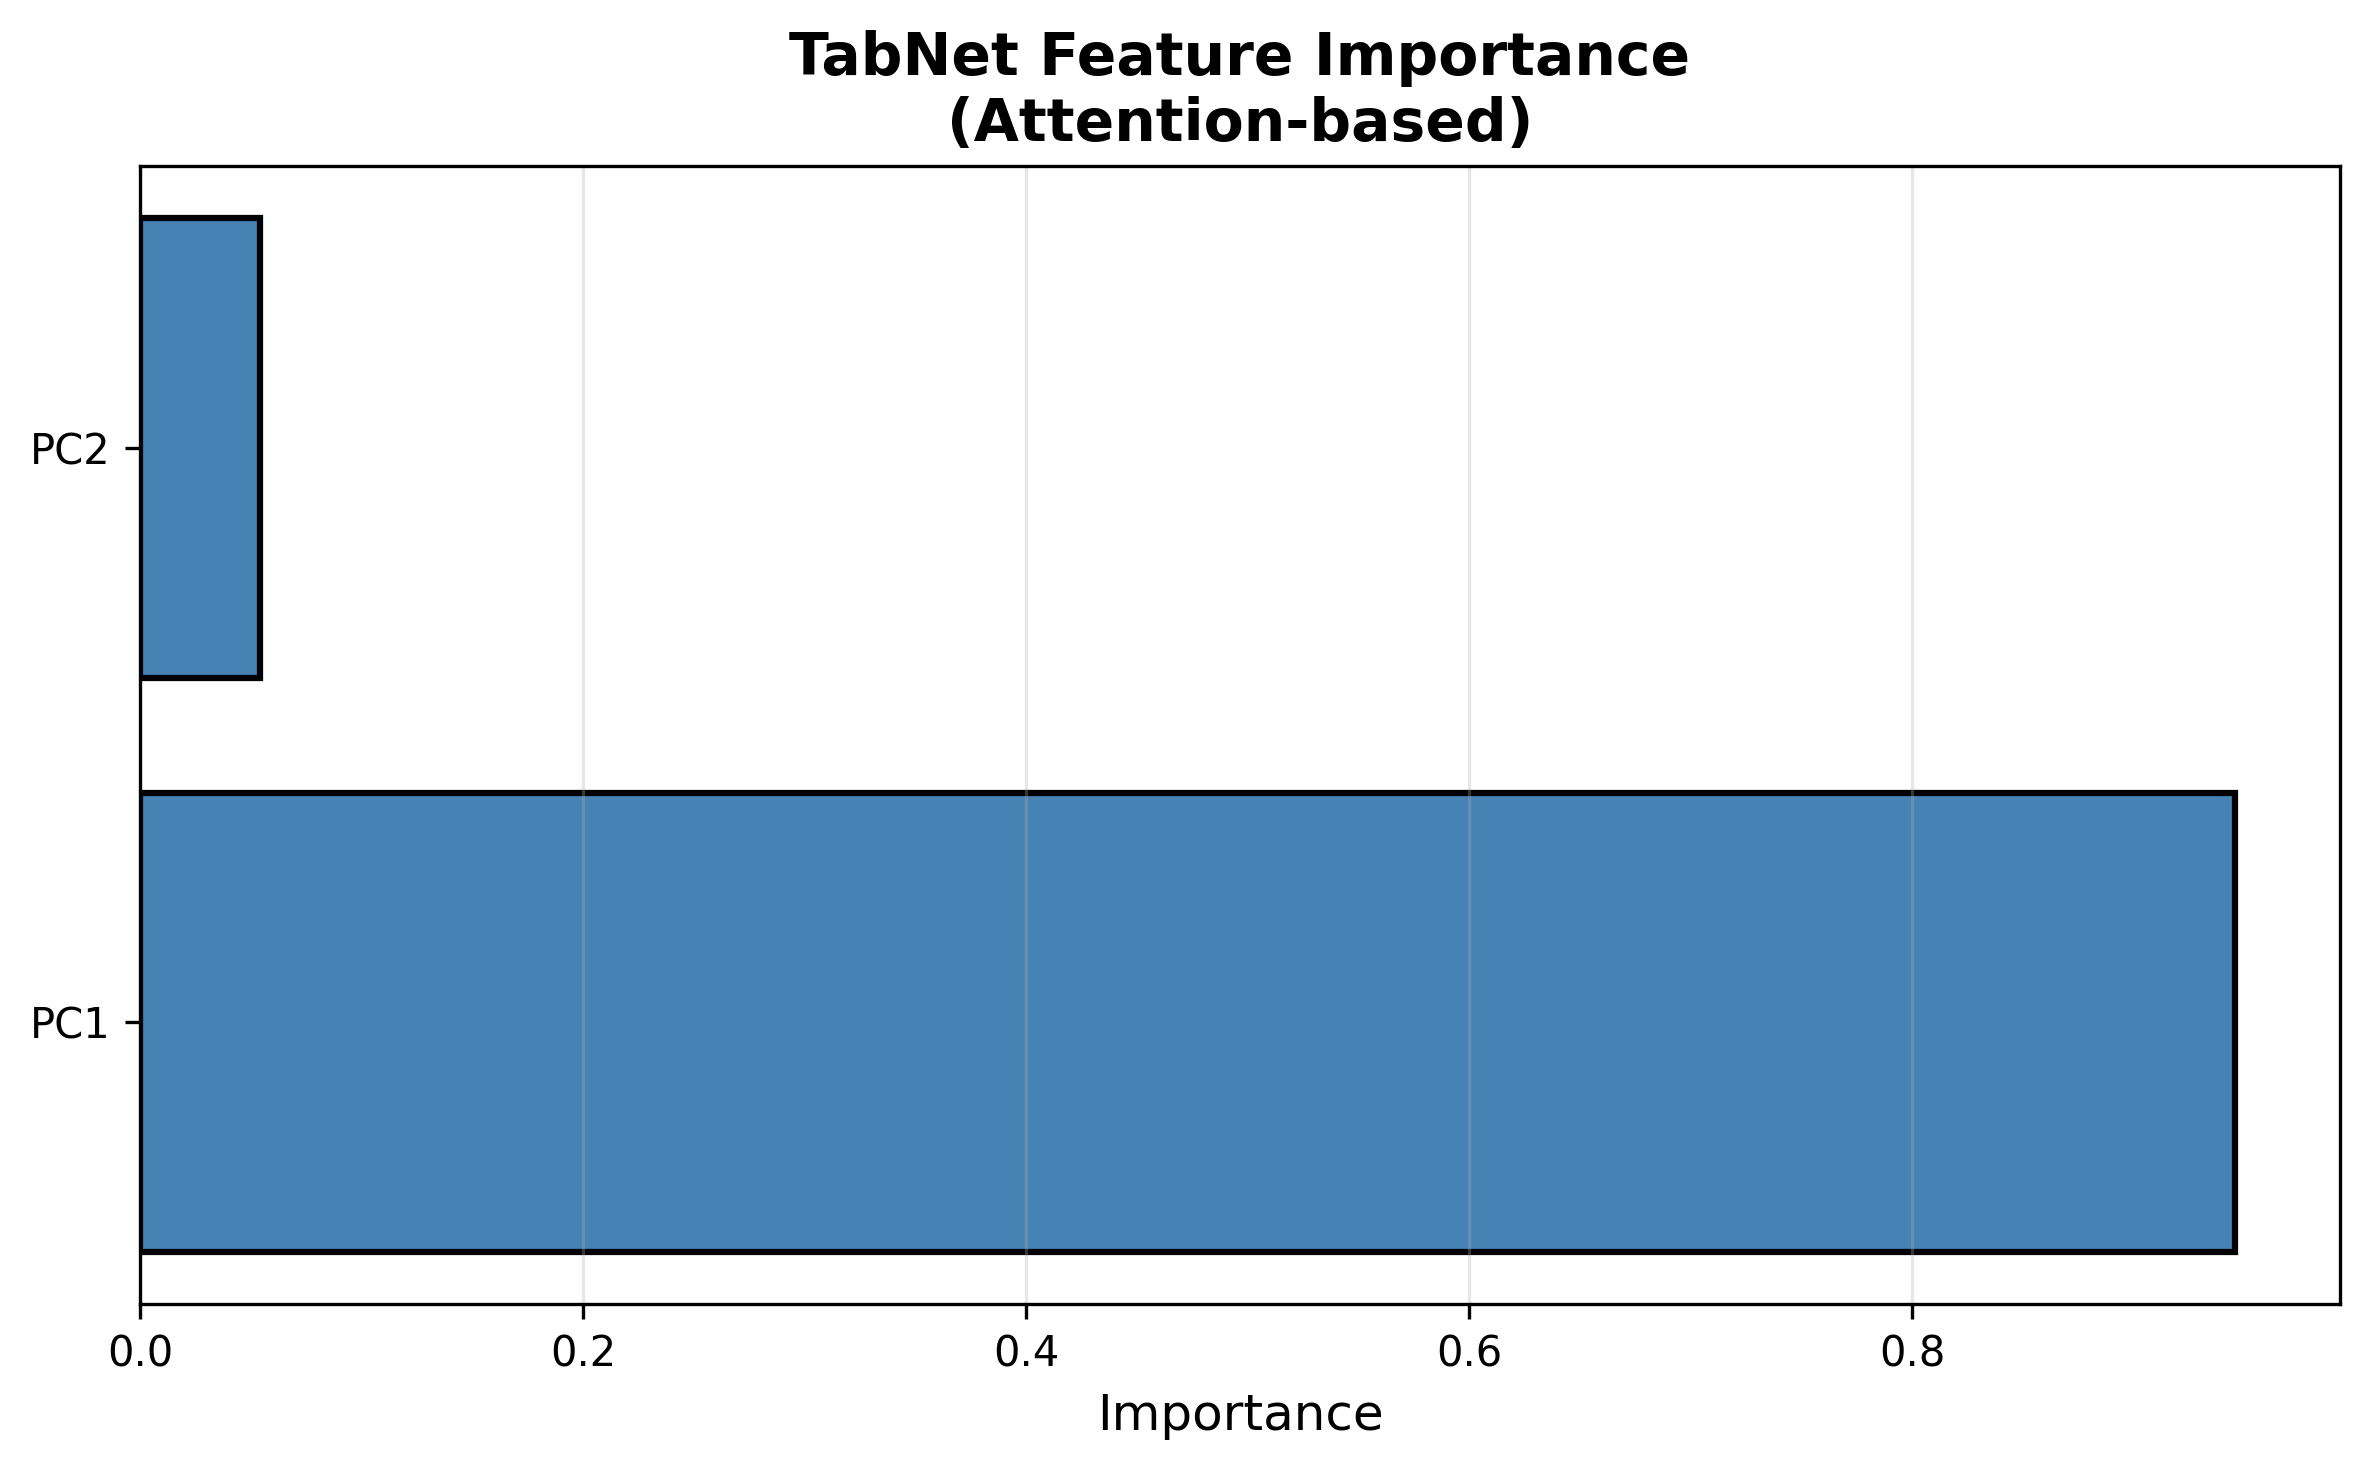


TABNET TRAINING CURVES
Available metrics: ['loss', 'lr', 'val_0_accuracy']

✓ Saved: tabnet_training_curves.png


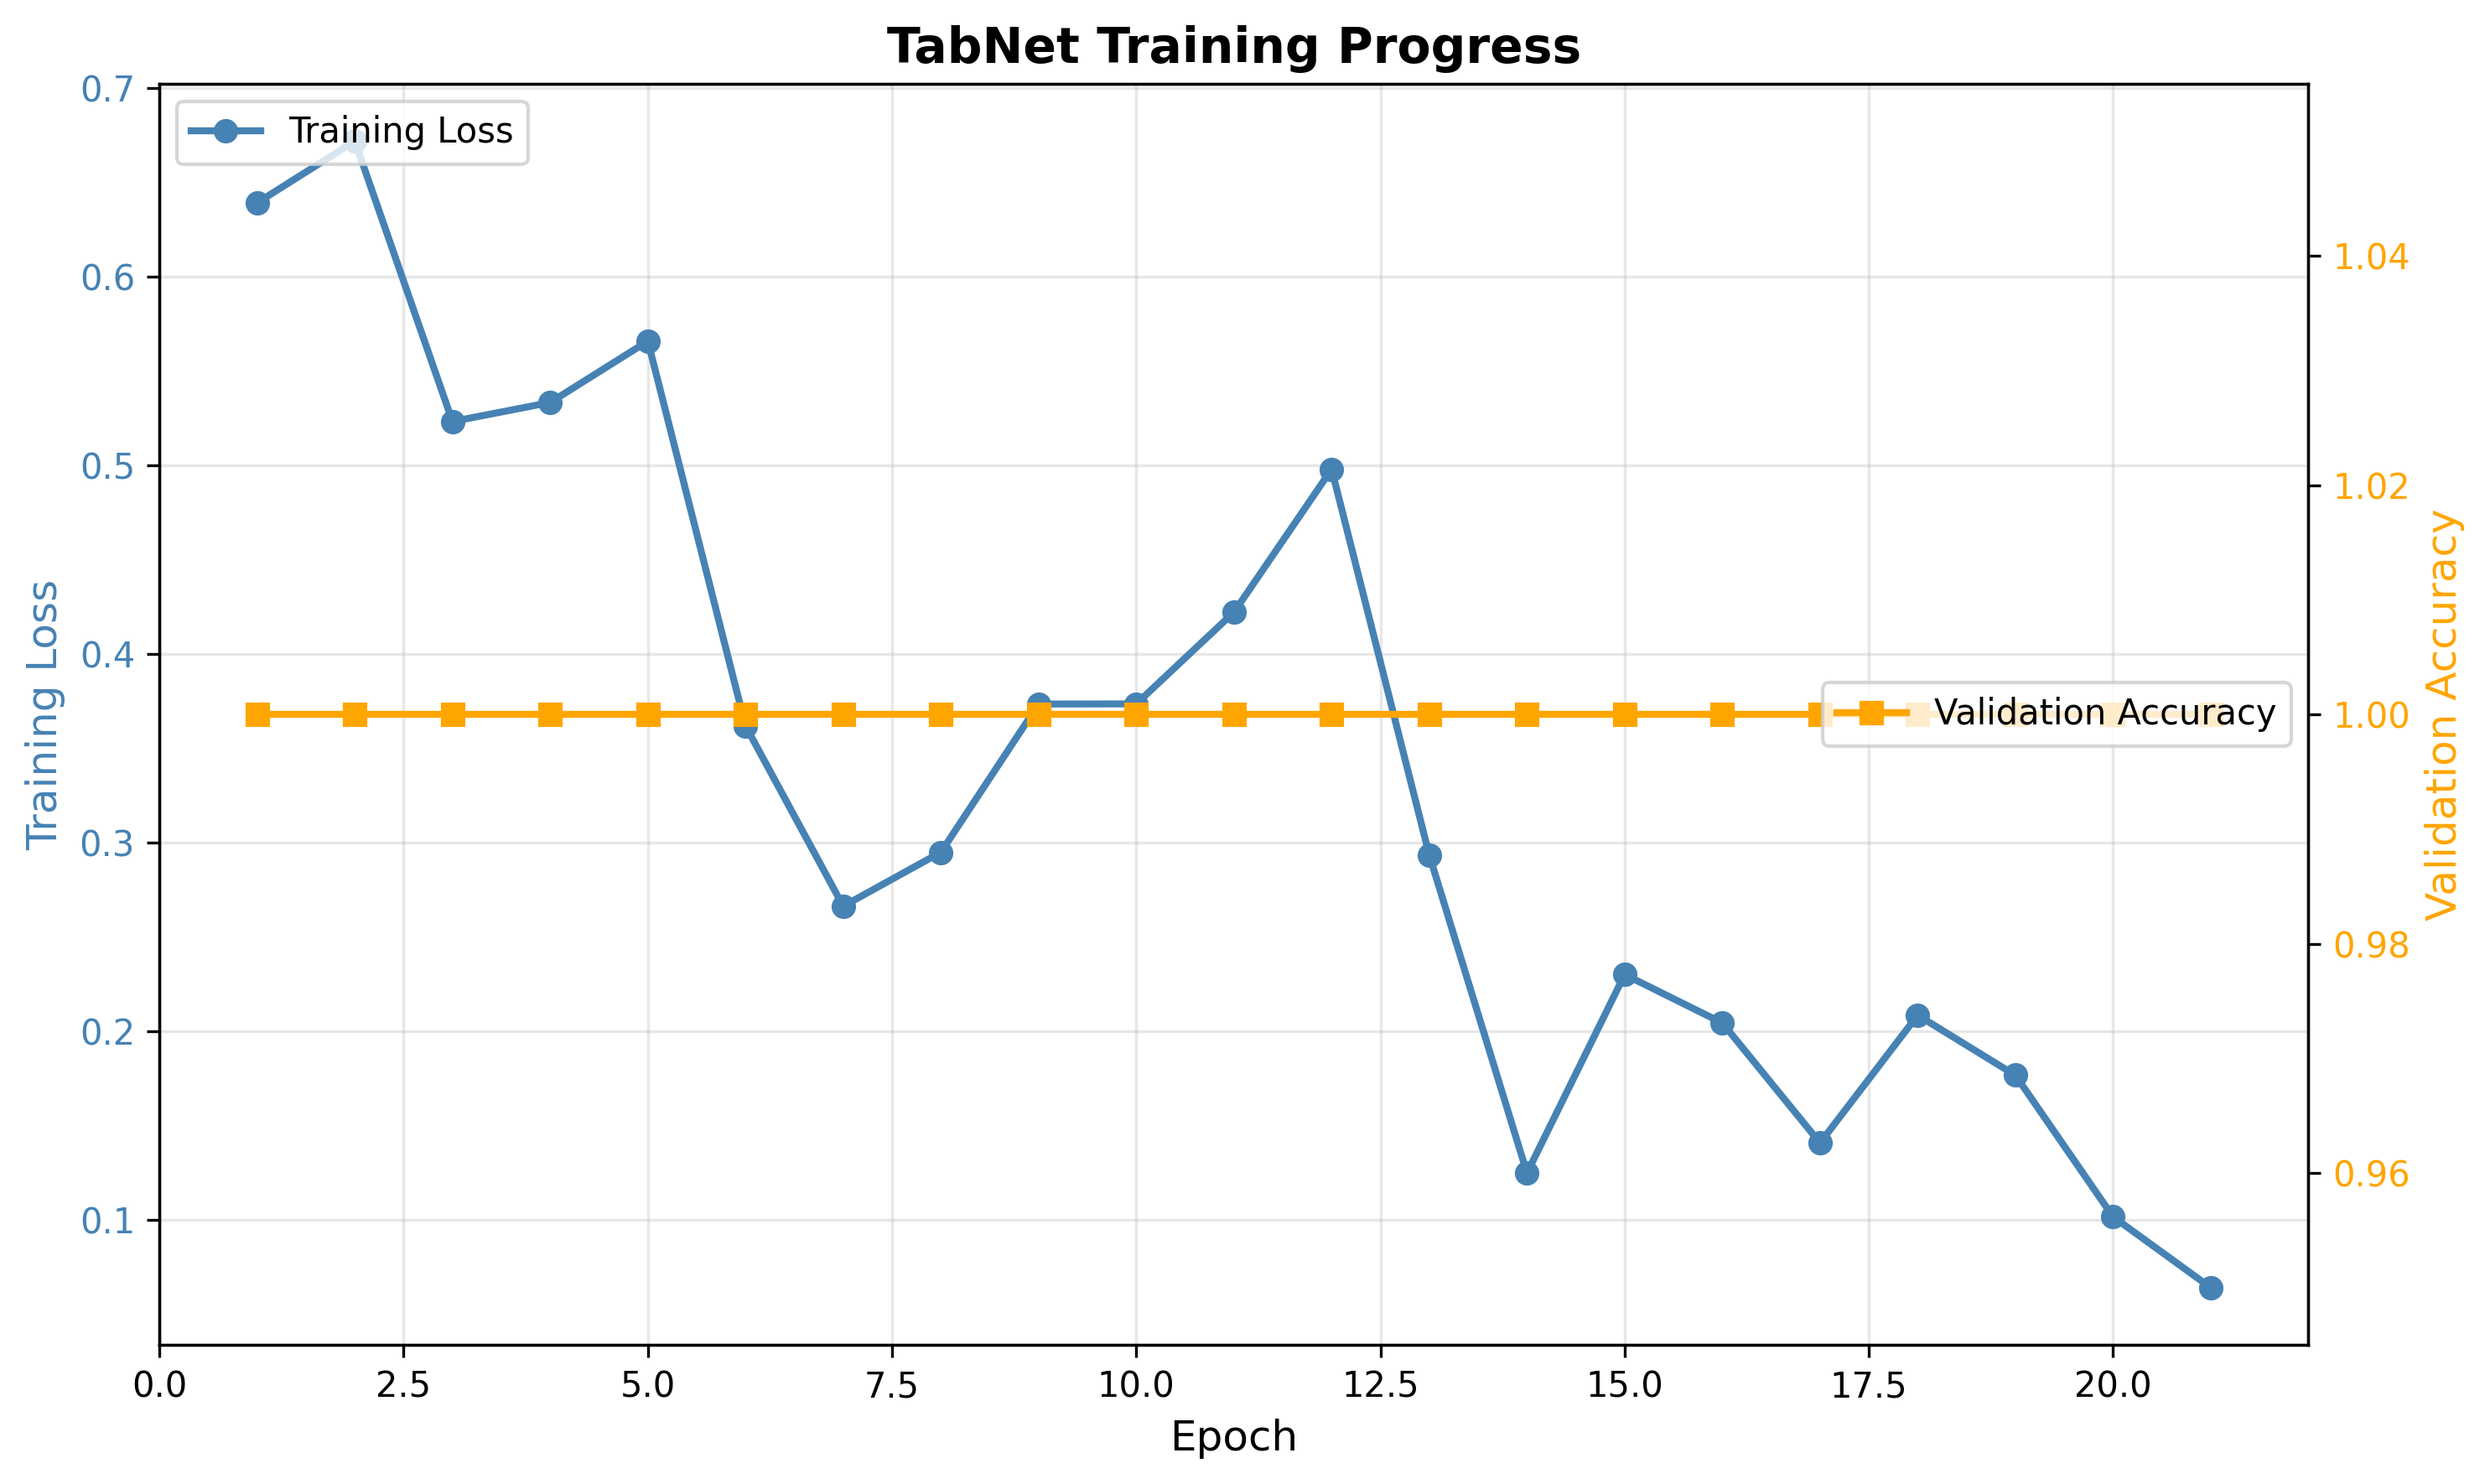


FINAL SUMMARY

📊 DATASET:
  Total samples: 20
  Training samples: 14
  Test samples: 6
  Features: 2 (PC1, PC2)
  Classes: 2 (Fir, Pine)

📈 TEST ACCURACY:
  LDA:           100.0%
  Random Forest: 100.0%
  TabNet:        100.0%

⚠️  OVERFITTING (Train - Test gap):
  LDA:           +0.0%
  Random Forest: +0.0%
  TabNet:        +0.0%

💡 INTERPRETATION:
  - LDA: Simple, interpretable, designed for small data ✅
  - Random Forest: Ensemble method, can handle non-linearity ⚠️
  - TabNet: Deep learning, attention mechanism, needs MUCH more data ❌
  - With only 14 training samples, TabNet will likely overfit badly

📁 Files saved:
  - all_models_comparison.png
  - tabnet_feature_importance.png
  - tabnet_training_curves.png

🎯 PROOF OF CONCEPT COMPLETE!
⚠️  Remember: TabNet is designed for 1000s of samples, not 20!
   Results shown here demonstrate the methodology, not optimal performance.


In [21]:
"""
TABNET COMPARISON (PROOF OF CONCEPT)
⚠️ WARNING: TabNet designed for 1000s of samples, you have 20!
This WILL overfit, but shown for proof of concept
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.dpi'] = 300

# =============================================================================
# INSTALL TABNET (RUN ONCE)
# =============================================================================
# !pip install pytorch-tabnet

# =============================================================================
# IMPORT TABNET
# =============================================================================
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    import torch
    tabnet_available = True
    print("✓ TabNet imported successfully")
except ImportError:
    print("❌ TabNet not installed. Run: pip install pytorch-tabnet")
    tabnet_available = False

# =============================================================================
# PREPARE DATA (SAME AS LDA AND RF)
# =============================================================================
print("\n" + "="*80)
print("PREPARING DATA FOR ALL THREE MODELS")
print("="*80)

# Use PC1 and PC2 (same as LDA and RF for fair comparison)
X_for_classification = X_pca[:, [0, 1]]

print(f"✓ Using PC1 and PC2")
print(f"  Features: {X_for_classification.shape}")
print(f"  Labels: {y.shape}")
print(f"  Fuel families: {np.unique(y)}")

# =============================================================================
# TRAIN/TEST SPLIT (SAME AS BEFORE - 70/30)
# =============================================================================
print("\n" + "="*80)
print("TRAIN/TEST SPLIT (70/30)")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X_for_classification,
    y,
    test_size=0.3,
    train_size=0.7,
    random_state=42,
    stratify=y
)

print(f"✓ Training: {len(X_train)} samples")
print(f"✓ Testing:  {len(X_test)} samples")

# Encode labels for TabNet (needs numeric labels)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(f"\n✓ Label encoding:")
for i, fuel in enumerate(label_encoder.classes_):
    print(f"  {fuel} → {i}")

# =============================================================================
# TRAIN ALL THREE MODELS
# =============================================================================
print("\n" + "="*80)
print("TRAINING ALL MODELS")
print("="*80)

# 1. LDA
print("\n1. Training LDA...")
lda = LDA()
lda.fit(X_train, y_train)
print("   ✓ LDA trained")

# 2. Random Forest
print("\n2. Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("   ✓ Random Forest trained")

# 3. TabNet
if tabnet_available:
    print("\n3. Training TabNet...")
    print("   ⚠️ WARNING: Only 14 training samples - TabNet will likely overfit!")

    tabnet = TabNetClassifier(
        n_d=4,                    # Dimension of hidden representation (SMALL - avoid overfitting)
        n_a=4,                    # Dimension of attention embedding (SMALL)
        n_steps=2,                # Number of decision steps (SMALL)
        gamma=1.5,                # Coefficient for feature reusage
        n_independent=1,          # Number of independent GLU layers
        n_shared=1,               # Number of shared GLU layers
        lambda_sparse=1e-4,       # Sparsity regularization
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        scheduler_params={"step_size":10, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',       # Attention mechanism
        seed=42,
        verbose=0
    )

    # Train with early stopping to prevent overfitting
    tabnet.fit(
        X_train, y_train_encoded,
        eval_set=[(X_test, y_test_encoded)],
        eval_metric=['accuracy'],
        max_epochs=100,
        patience=20,              # Stop if no improvement for 20 epochs
        batch_size=8,             # Small batch for small dataset
        virtual_batch_size=4,
        num_workers=0,
        drop_last=False
    )
    print("   ✓ TabNet trained")
else:
    print("\n3. ❌ TabNet not available (not installed)")
    tabnet = None

# =============================================================================
# COMPARE ACCURACIES
# =============================================================================
print("\n" + "="*80)
print("ACCURACY COMPARISON")
print("="*80)

# LDA scores
lda_train_acc = lda.score(X_train, y_train)
lda_test_acc = lda.score(X_test, y_test)

# Random Forest scores
rf_train_acc = rf.score(X_train, y_train)
rf_test_acc = rf.score(X_test, y_test)

# TabNet scores
if tabnet is not None:
    # TabNet predictions
    tabnet_train_pred = tabnet.predict(X_train)
    tabnet_test_pred = tabnet.predict(X_test)

    tabnet_train_acc = (tabnet_train_pred == y_train_encoded).mean()
    tabnet_test_acc = (tabnet_test_pred == y_test_encoded).mean()
else:
    tabnet_train_acc = 0
    tabnet_test_acc = 0

# Display comparison table
print(f"\n{'Model':<20} {'Training Acc':<15} {'Test Acc':<15} {'Overfitting Gap':<15}")
print("-" * 70)
print(f"{'LDA':<20} {lda_train_acc*100:>6.1f}%        {lda_test_acc*100:>6.1f}%        {(lda_train_acc-lda_test_acc)*100:>+6.1f}%")
print(f"{'Random Forest':<20} {rf_train_acc*100:>6.1f}%        {rf_test_acc*100:>6.1f}%        {(rf_train_acc-rf_test_acc)*100:>+6.1f}%")
if tabnet is not None:
    print(f"{'TabNet':<20} {tabnet_train_acc*100:>6.1f}%        {tabnet_test_acc*100:>6.1f}%        {(tabnet_train_acc-tabnet_test_acc)*100:>+6.1f}%")

# Determine winner
models_scores = {
    'LDA': lda_test_acc,
    'Random Forest': rf_test_acc
}
if tabnet is not None:
    models_scores['TabNet'] = tabnet_test_acc

winner = max(models_scores, key=models_scores.get)
print(f"\n🏆 BEST TEST ACCURACY: {winner} ({models_scores[winner]*100:.1f}%)")

# =============================================================================
# CONFUSION MATRICES
# =============================================================================
print("\n" + "="*80)
print("CONFUSION MATRICES (TEST SET)")
print("="*80)

y_pred_lda = lda.predict(X_test)
y_pred_rf = rf.predict(X_test)

print("\nLDA:")
print(pd.crosstab(y_test, y_pred_lda, rownames=['Actual'], colnames=['Predicted']))

print("\nRandom Forest:")
print(pd.crosstab(y_test, y_pred_rf, rownames=['Actual'], colnames=['Predicted']))

if tabnet is not None:
    y_pred_tabnet = label_encoder.inverse_transform(tabnet_test_pred)
    print("\nTabNet:")
    print(pd.crosstab(y_test, y_pred_tabnet, rownames=['Actual'], colnames=['Predicted']))

# =============================================================================
# VISUALIZE DECISION BOUNDARIES (ALL THREE)
# =============================================================================
print("\n" + "="*80)
print("VISUALIZING DECISION BOUNDARIES")
print("="*80)

n_models = 3 if tabnet is not None else 2
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))

if n_models == 2:
    axes = [axes[0], axes[1], None]

# Create mesh
h = 0.02
x_min, x_max = X_for_classification[:, 0].min() - 1, X_for_classification[:, 0].max() + 1
y_min, y_max = X_for_classification[:, 1].min() - 1, X_for_classification[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

colors_fuel = {'Pine': '#1f77b4', 'Fir': '#ff7f0e', 'Spruce': '#2ca02c'}

# Get variance explained for axis labels
var1 = pca_full.explained_variance_ratio_[0] * 100
var2 = pca_full.explained_variance_ratio_[1] * 100

# Plot 1: LDA
ax1 = axes[0]
Z_lda = lda.predict(np.c_[xx.ravel(), yy.ravel()])
fuel_to_num = {fuel: i for i, fuel in enumerate(np.unique(y))}
Z_lda_num = np.array([fuel_to_num[fuel] for fuel in Z_lda]).reshape(xx.shape)
ax1.contourf(xx, yy, Z_lda_num, alpha=0.3, cmap='coolwarm')

for fuel in np.unique(y):
    mask = y == fuel
    ax1.scatter(X_for_classification[mask, 0], X_for_classification[mask, 1],
               c=[colors_fuel.get(fuel, 'gray')], s=200, edgecolors='black',
               linewidths=1.5, label=fuel, alpha=0.8)

ax1.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=11)
ax1.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=11)
ax1.set_title(f'LDA\nTest Acc: {lda_test_acc*100:.1f}%', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Random Forest
ax2 = axes[1]
Z_rf = rf.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rf_num = np.array([fuel_to_num[fuel] for fuel in Z_rf]).reshape(xx.shape)
ax2.contourf(xx, yy, Z_rf_num, alpha=0.3, cmap='coolwarm')

for fuel in np.unique(y):
    mask = y == fuel
    ax2.scatter(X_for_classification[mask, 0], X_for_classification[mask, 1],
               c=[colors_fuel.get(fuel, 'gray')], s=200, edgecolors='black',
               linewidths=1.5, label=fuel, alpha=0.8)

ax2.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=11)
ax2.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=11)
ax2.set_title(f'Random Forest\nTest Acc: {rf_test_acc*100:.1f}%', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: TabNet
if tabnet is not None and axes[2] is not None:
    ax3 = axes[2]
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z_tabnet = tabnet.predict(mesh_points)
    Z_tabnet_labels = label_encoder.inverse_transform(Z_tabnet)
    Z_tabnet_num = np.array([fuel_to_num[fuel] for fuel in Z_tabnet_labels]).reshape(xx.shape)
    ax3.contourf(xx, yy, Z_tabnet_num, alpha=0.3, cmap='coolwarm')

    for fuel in np.unique(y):
        mask = y == fuel
        ax3.scatter(X_for_classification[mask, 0], X_for_classification[mask, 1],
                   c=[colors_fuel.get(fuel, 'gray')], s=200, edgecolors='black',
                   linewidths=1.5, label=fuel, alpha=0.8)

    ax3.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=11)
    ax3.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=11)
    ax3.set_title(f'TabNet\nTest Acc: {tabnet_test_acc*100:.1f}%', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: all_models_comparison.png")
plt.show()

# =============================================================================
# TABNET FEATURE IMPORTANCE (ATTENTION-BASED)
# =============================================================================
if tabnet is not None:
    print("\n" + "="*80)
    print("TABNET FEATURE IMPORTANCE (ATTENTION MECHANISM)")
    print("="*80)

    # Get feature importance
    feature_importances = tabnet.feature_importances_

    feature_names = ['PC1', 'PC2']
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    }).sort_values('Importance', ascending=False)

    print("\nFeature importance:")
    print(importance_df.to_string(index=False))

    # Visualize
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(importance_df['Feature'], importance_df['Importance'],
            color='steelblue', edgecolor='black', linewidth=1.5)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title('TabNet Feature Importance\n(Attention-based)',
                fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('tabnet_feature_importance.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: tabnet_feature_importance.png")
    plt.show()

# =============================================================================
# TRAINING CURVES (TABNET ONLY)
# =============================================================================
if tabnet is not None:
    print("\n" + "="*80)
    print("TABNET TRAINING CURVES")
    print("="*80)

    # Get training history - TabNet stores it differently
    try:
        # Access the history dictionary from the History object
        history_dict = tabnet.history

        # Check if we have any training history
        if hasattr(history_dict, 'history') and len(history_dict.history) > 0:
            history = history_dict.history
        elif hasattr(history_dict, 'epoch_metrics') and len(history_dict.epoch_metrics) > 0:
            history = history_dict.epoch_metrics
        else:
            # Try to convert to dict if it's a different object
            history = {}
            if hasattr(history_dict, 'items'):
                history = dict(history_dict.items())
            elif hasattr(history_dict, '__dict__'):
                history = history_dict.__dict__

        # Plot if we have data
        if len(history) > 0:
            fig, ax = plt.subplots(figsize=(10, 6))

            # Find what keys exist in history
            print(f"Available metrics: {list(history.keys())}")

            # Training loss
            loss_key = None
            for key in ['loss', 'train_loss', 'training_loss']:
                if key in history:
                    loss_key = key
                    break

            if loss_key is not None:
                epochs = range(1, len(history[loss_key]) + 1)
                ax.plot(epochs, history[loss_key], 'o-', label='Training Loss',
                       linewidth=2, markersize=6, color='steelblue')

            # Validation accuracy
            acc_key = None
            for key in ['val_0_accuracy', 'valid_0_accuracy', 'val_accuracy']:
                if key in history:
                    acc_key = key
                    break

            if acc_key is not None:
                ax2 = ax.twinx()
                ax2.plot(epochs, history[acc_key], 's-',
                        label='Validation Accuracy', linewidth=2, markersize=6,
                        color='orange')
                ax2.set_ylabel('Validation Accuracy', fontsize=12, color='orange')
                ax2.tick_params(axis='y', labelcolor='orange')
                ax2.legend(loc='center right', fontsize=10)

            ax.set_xlabel('Epoch', fontsize=12)
            ax.set_ylabel('Training Loss', fontsize=12, color='steelblue')
            ax.set_title('TabNet Training Progress', fontsize=14, fontweight='bold')
            ax.tick_params(axis='y', labelcolor='steelblue')
            ax.legend(loc='upper left', fontsize=10)
            ax.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.savefig('tabnet_training_curves.png', dpi=300, bbox_inches='tight')
            print("\n✓ Saved: tabnet_training_curves.png")
            plt.show()
        else:
            print("\n⚠️ No training history available to plot")

    except Exception as e:
        print(f"\n⚠️ Could not plot training curves: {e}")
        print("   (This is OK - training curves are optional)")

# =============================================================================
# FINAL COMPARISON SUMMARY
# =============================================================================
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"\n📊 DATASET:")
print(f"  Total samples: {len(X_for_classification)}")
print(f"  Training samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")
print(f"  Features: 2 (PC1, PC2)")
print(f"  Classes: {len(np.unique(y))} ({', '.join(np.unique(y))})")

print(f"\n📈 TEST ACCURACY:")
print(f"  LDA:           {lda_test_acc*100:.1f}%")
print(f"  Random Forest: {rf_test_acc*100:.1f}%")
if tabnet is not None:
    print(f"  TabNet:        {tabnet_test_acc*100:.1f}%")

print(f"\n⚠️  OVERFITTING (Train - Test gap):")
print(f"  LDA:           {(lda_train_acc - lda_test_acc)*100:+.1f}%")
print(f"  Random Forest: {(rf_train_acc - rf_test_acc)*100:+.1f}%")
if tabnet is not None:
    print(f"  TabNet:        {(tabnet_train_acc - tabnet_test_acc)*100:+.1f}%")

print(f"\n💡 INTERPRETATION:")
print(f"  - LDA: Simple, interpretable, designed for small data ✅")
print(f"  - Random Forest: Ensemble method, can handle non-linearity ⚠️")
if tabnet is not None:
    print(f"  - TabNet: Deep learning, attention mechanism, needs MUCH more data ❌")
    print(f"  - With only {len(X_train)} training samples, TabNet will likely overfit badly")

print(f"\n📁 Files saved:")
print("  - all_models_comparison.png")
if tabnet is not None:
    print("  - tabnet_feature_importance.png")
    print("  - tabnet_training_curves.png")

print("\n🎯 PROOF OF CONCEPT COMPLETE!")
print("⚠️  Remember: TabNet is designed for 1000s of samples, not 20!")
print("   Results shown here demonstrate the methodology, not optimal performance.")